# Experiment 1: 5 WMO rain class classification
---
### Dataset: Mamirauá Sustainable Development Institute (IDSM)

Classifiers: 
- Stocastic Gradient Descent (SGD);
- Logistic Regression (LR);
- Random Forest (RF);
- Extreme Gradient Boost (XGB).

Rain Classes:
- No Rain ( $0~mm \cdot h^{-1}$ );
- Light ( $< 2.5~mm \cdot h^{-1}$ );
- Moderate ( $2.5$ to $10.0~mm \cdot h^{-1}$ );
- Heavy ( $10.0$ to $50.0~mm \cdot h^{-1}$ );
- Violent ( $> 50.0~mm \cdot h^{-1}$ ).


NOTE 1: Some functions of this notebook will not work because they are unavailable due to being designed for ploting.

NOTE 2: This notebook will be updated for full functionality in the next version.

In [1]:
DATASET = 'IDSM'
CONTENT = 'dry/wet'
GRANULARITY = 5
TARGET_COL = 'category'

# Imports and Configurations

In [2]:
import os
import numpy as np
import pandas as pd
import sys
from pathlib import Path
import joblib
import warnings
warnings.filterwarnings('ignore')
from typing import Dict, List, Any

current_path = Path.cwd()
PROJECT_ROOT = None

for p in [current_path, current_path.parent, current_path.parent.parent]:
    if (p / "rainfall_acoustic_classification").exists():
        PROJECT_ROOT = p
        break

if PROJECT_ROOT:
    if str(PROJECT_ROOT) not in sys.path:
        sys.path.insert(0, str(PROJECT_ROOT))
    print(f"Project root added to sys.path")
else:
    print("ERROR: Unable to find the project root.")

from rainfall_acoustic_classification.visualization import VisualizationEngine
from rainfall_acoustic_classification.utils import get_standard_logger

# Feature Engineering
from rainfall_acoustic_classification.feature_engineering import (
    ExperimentCreator, ExperimentConfig, 
    select_features,
    plot_correlation_matrix, plot_gini_importances, plot_feature_separability
)

# Modeling
from rainfall_acoustic_classification.modeling import (
    ClassifierFactory,
    optimize_model,
    evaluate_model
)

DATA_DIR = PROJECT_ROOT / "data" / "processed" / DATASET

Project root added to sys.path


# Data Loading and Mapping

In [3]:
df_train_metrics = pd.read_csv(DATA_DIR /  f"{DATASET}_train_metrics.csv")
df_val_metrics = pd.read_csv(DATA_DIR / f"{DATASET}_val_metrics.csv")
df_test_metrics = pd.read_csv(DATA_DIR / f"{DATASET}_test_metrics.csv")

print(f"Raw Shapes -> Train: {df_train_metrics.shape}, Val: {df_val_metrics.shape}, Test: {df_test_metrics.shape}")

Raw Shapes -> Train: (28331, 113), Val: (2618, 112), Test: (2618, 112)


In [4]:
exp_config = ExperimentConfig(
    content=CONTENT,
    granularity=GRANULARITY, 
    label_col=TARGET_COL,
)

X_train_metrics, y_train_metrics, _ = ExperimentCreator.extract_X_y_meta(df_train_metrics, config=exp_config)
X_train, y_train = ExperimentCreator.apply_experiment_rules(X_train_metrics, y_train_metrics, config=exp_config)


X_val_metrics, y_val_metrics, _ = ExperimentCreator.extract_X_y_meta(df_val_metrics, config=exp_config)
X_val, y_val = ExperimentCreator.apply_experiment_rules(X_val_metrics, y_val_metrics, config=exp_config)


X_test_metrics, y_test_metrics, _ = ExperimentCreator.extract_X_y_meta(df_test_metrics, config=exp_config)
X_test, y_test = ExperimentCreator.apply_experiment_rules(X_test_metrics, y_test_metrics, config=exp_config)

print(f"Classes post mapping -> Train: {y_train.unique()}, Val: {y_val.unique()}, Test: {y_test.unique()}")

11:01:13 - [ExperimentCreator] - INFO - Applying Smart Rules -> Content: 'dry/wet' | Granularity: 5
11:01:13 - [ExperimentCreator] - INFO - Applying Smart Rules -> Content: 'dry/wet' | Granularity: 5
11:01:13 - [ExperimentCreator] - INFO - Applying Smart Rules -> Content: 'dry/wet' | Granularity: 5
Classes post mapping -> Train: <ArrowStringArray>
['No Rain', 'Moderate', 'Heavy', 'Light', 'Violent']
Length: 5, dtype: str, Val: <ArrowStringArray>
['Moderate', 'Light', 'No Rain', 'Heavy', 'Violent']
Length: 5, dtype: str, Test: <ArrowStringArray>
['Light', 'Violent', 'Moderate', 'No Rain', 'Heavy']
Length: 5, dtype: str


# Feature Engineering (Metrics Selection and PSD)

In [5]:
viz_engine = VisualizationEngine()
palette = viz_engine.get_rain_color_palette()
rain_palette = dict(list(palette.items())[:5])
print(rain_palette)


{'No Rain': '#5c01a6', 'Light': '#9c179e', 'Moderate': '#cc4778', 'Heavy': '#ed7953', 'Violent': '#fdb42f'}


## Metrics Selection

In [6]:
X_train_selected_metrics, gini_importances_dict = select_features(
    X_train,
    y_train,
    corr_threshold=0.85,
    gini_threshold='1.5*mean',
    random_state=42
)

survivors = X_train_selected_metrics.columns.to_list()
print(f"Original Features: {X_train.shape[1]} -> Selected: {X_train_selected_metrics.shape[1]}")
print(f"Selected ones: {survivors}")

X_val_selected_metrics, _ = select_features(
    X_val,
    y_val,
    target_features=survivors
)
X_test_selected_metrics, _ = select_features(
    X_test,
    y_test,
    target_features=survivors
)

11:01:14 - [FeatureSelector] - INFO - Pipeline complete. Selected 11 features out of 91. (Gini Thresh: 0.0263)
Original Features: 91 -> Selected: 11
Selected ones: ['NDSI', 'ratioBA', 'anthro_energy', 'bio_energy', 'mfcc_1', 'mfcc_7', 'mfcc_13', 'spec_bandwidth_mean', 'ACI', 'rms_std', 'zcr_std']


10:53:24 - [FeaturePlots] - INFO - Generating Correlation Matrix plot...
10:53:24 - [VizEngine] - INFO - Figure saved: IDSM_correlation_matrix_5c.pdf


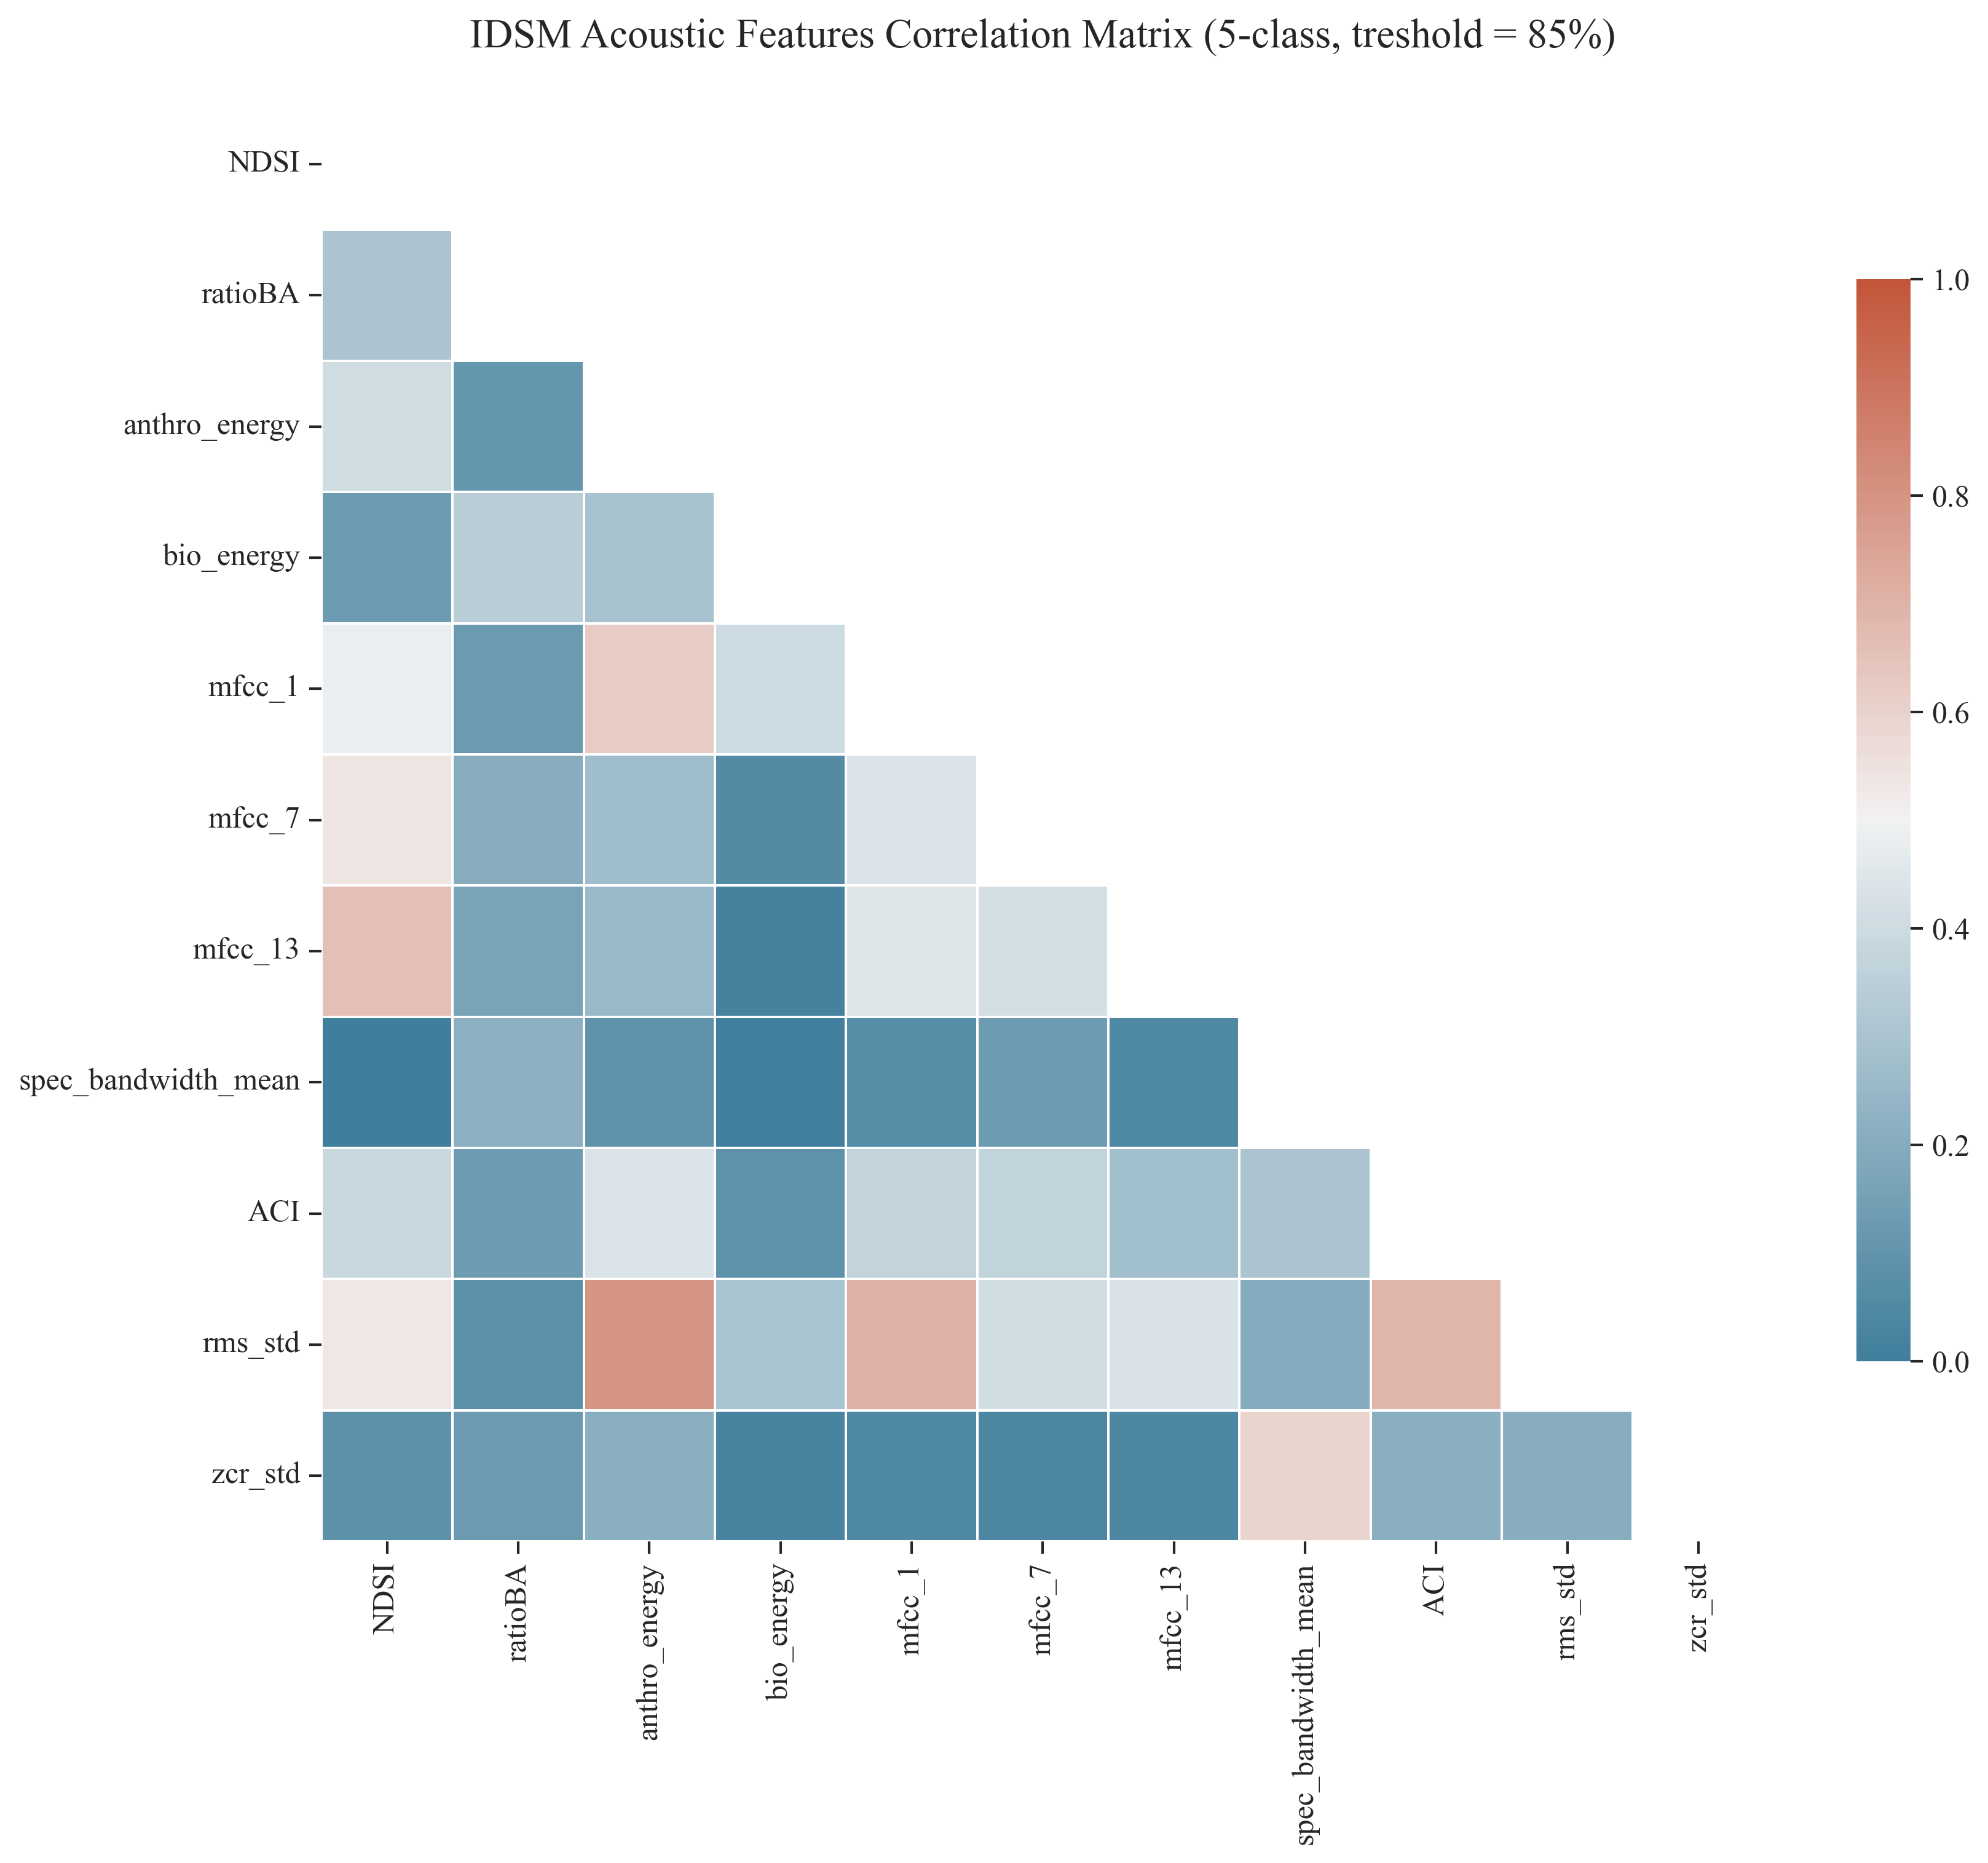

In [7]:
plt_cm = plot_correlation_matrix(
    X=X_train_selected_metrics,
    title="IDSM Acoustic Features Correlation Matrix (5-class, treshold = 85%)"
)
viz_engine.save_figure(fig=plt_cm, filename="IDSM_correlation_matrix_5c", formats=['pdf'])

11:00:43 - [FeaturePlots] - INFO - Generating Gini Importances lollipop plot...
11:00:43 - [VizEngine] - INFO - Figure saved: IDSM_gini_5c.pdf


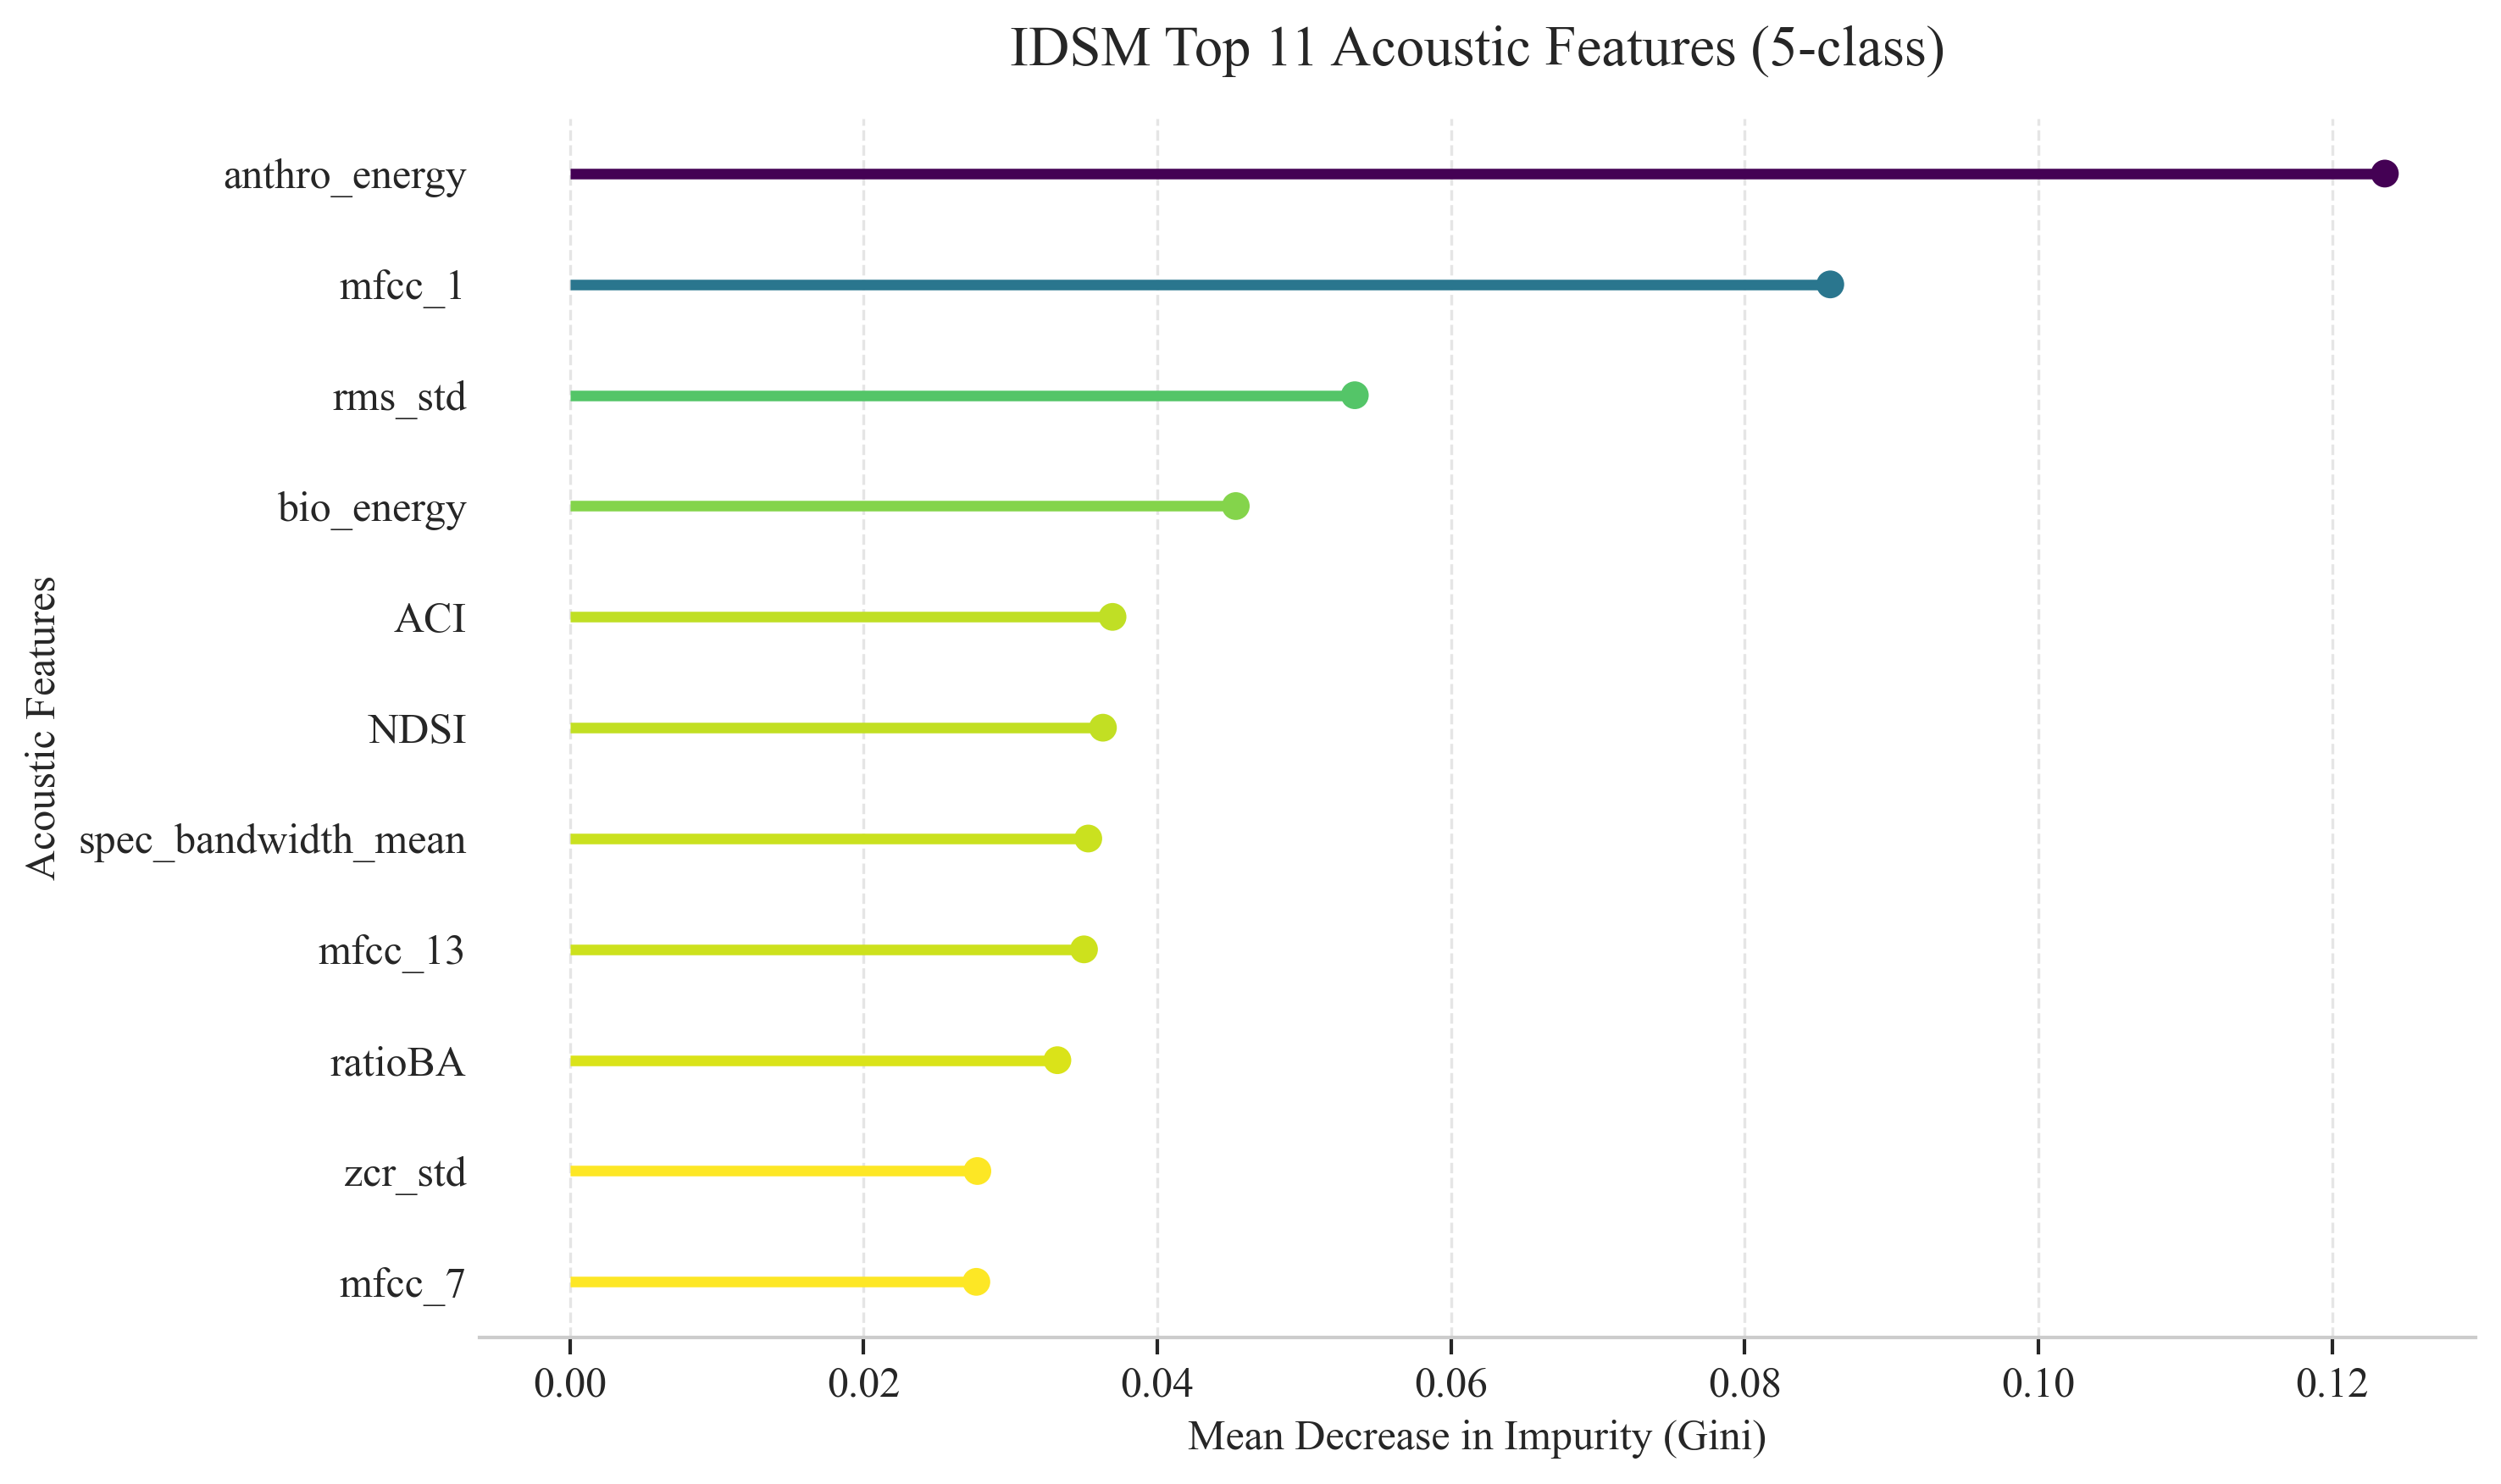

In [7]:
plt_gini = plot_gini_importances(
    gini_dict=gini_importances_dict,
    top_n=11,
    title="IDSM Top 11 Acoustic Features (5-class)"
)
viz_engine.save_figure(fig=plt_gini, filename="IDSM_gini_5c", formats=['pdf'])

11:02:16 - [FeaturePlots] - INFO - Generating integrated Feature Separability boxplot...
11:02:16 - [VizEngine] - INFO - Figure saved: IDSM_feature_separability_5c.pdf


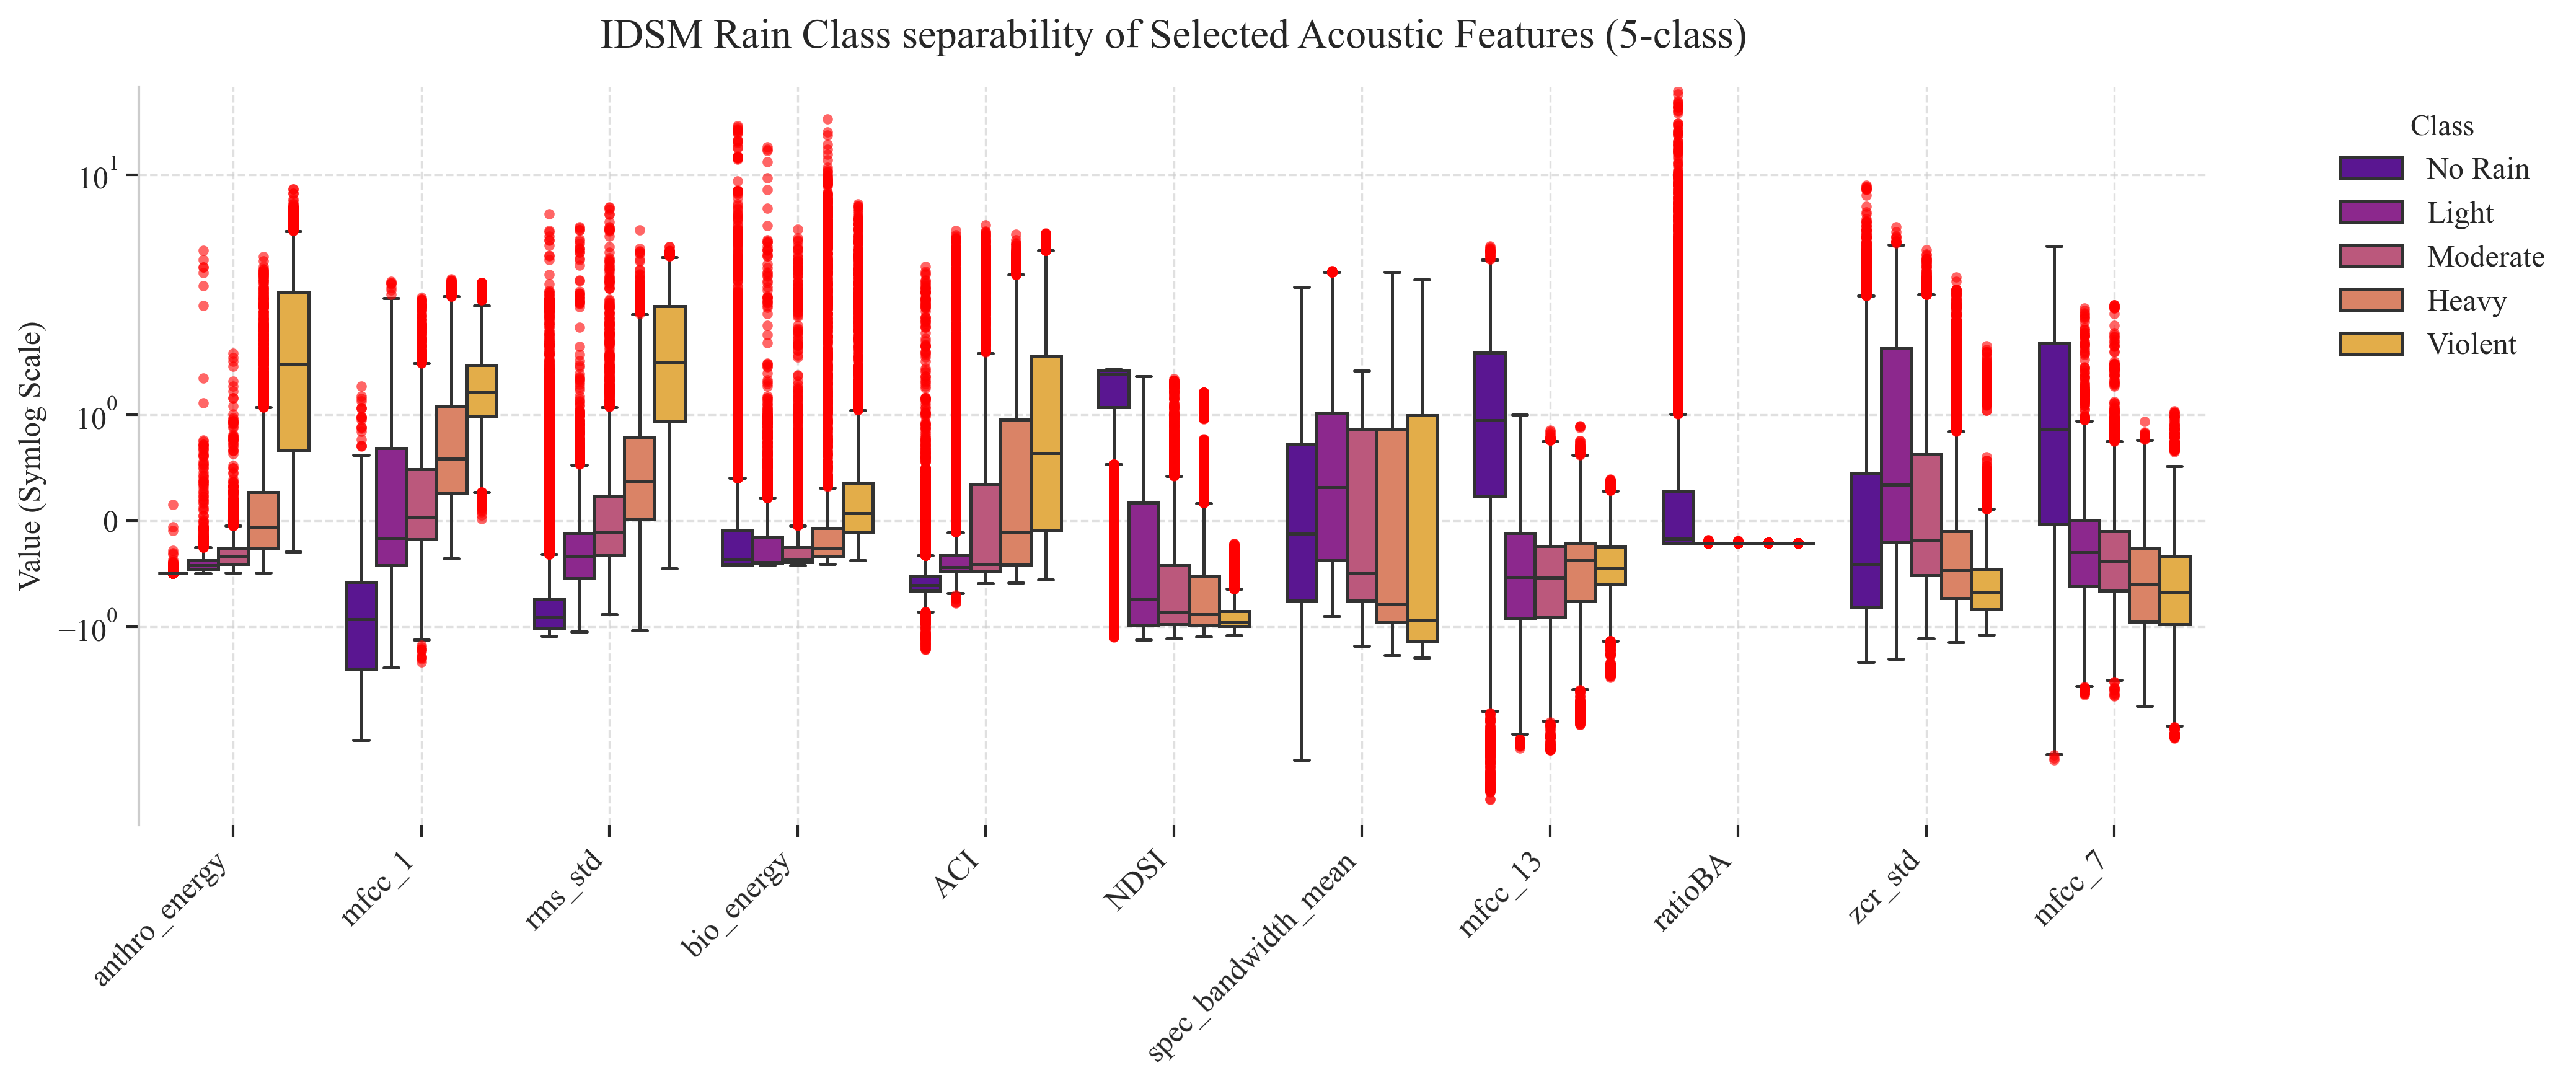

In [9]:
plt_fs1 = plot_feature_separability(
    X=X_train_selected_metrics,
    y=y_train,
    features_to_plot=['anthro_energy', 'mfcc_1', 'rms_std', 'bio_energy', 'ACI', 'NDSI', 'spec_bandwidth_mean', 'mfcc_13', 'ratioBA', 'zcr_std', 'mfcc_7'],
    title="IDSM Rain Class separability of Selected Acoustic Features (5-class)",
    palette=rain_palette
)
viz_engine.save_figure(fig=plt_fs1, filename="IDSM_feature_separability_5c", formats=['pdf'])

## Power Spectrum Density (PSD) Mean

In [9]:
X_train_psd, _ = select_features(
    X_train,
    y_train,
    target_features=['psd_mean']
)

X_val_psd, _ = select_features(
    X_val,
    y_val,
    target_features=['psd_mean']
)

X_test_psd, _ = select_features(
    X_test,
    y_test,
    target_features=['psd_mean']
)

11:30:58 - [FeaturePlots] - INFO - Generating integrated Feature Separability boxplot...
11:30:59 - [VizEngine] - INFO - Figure saved: IDSM_psd_separability_5c.pdf


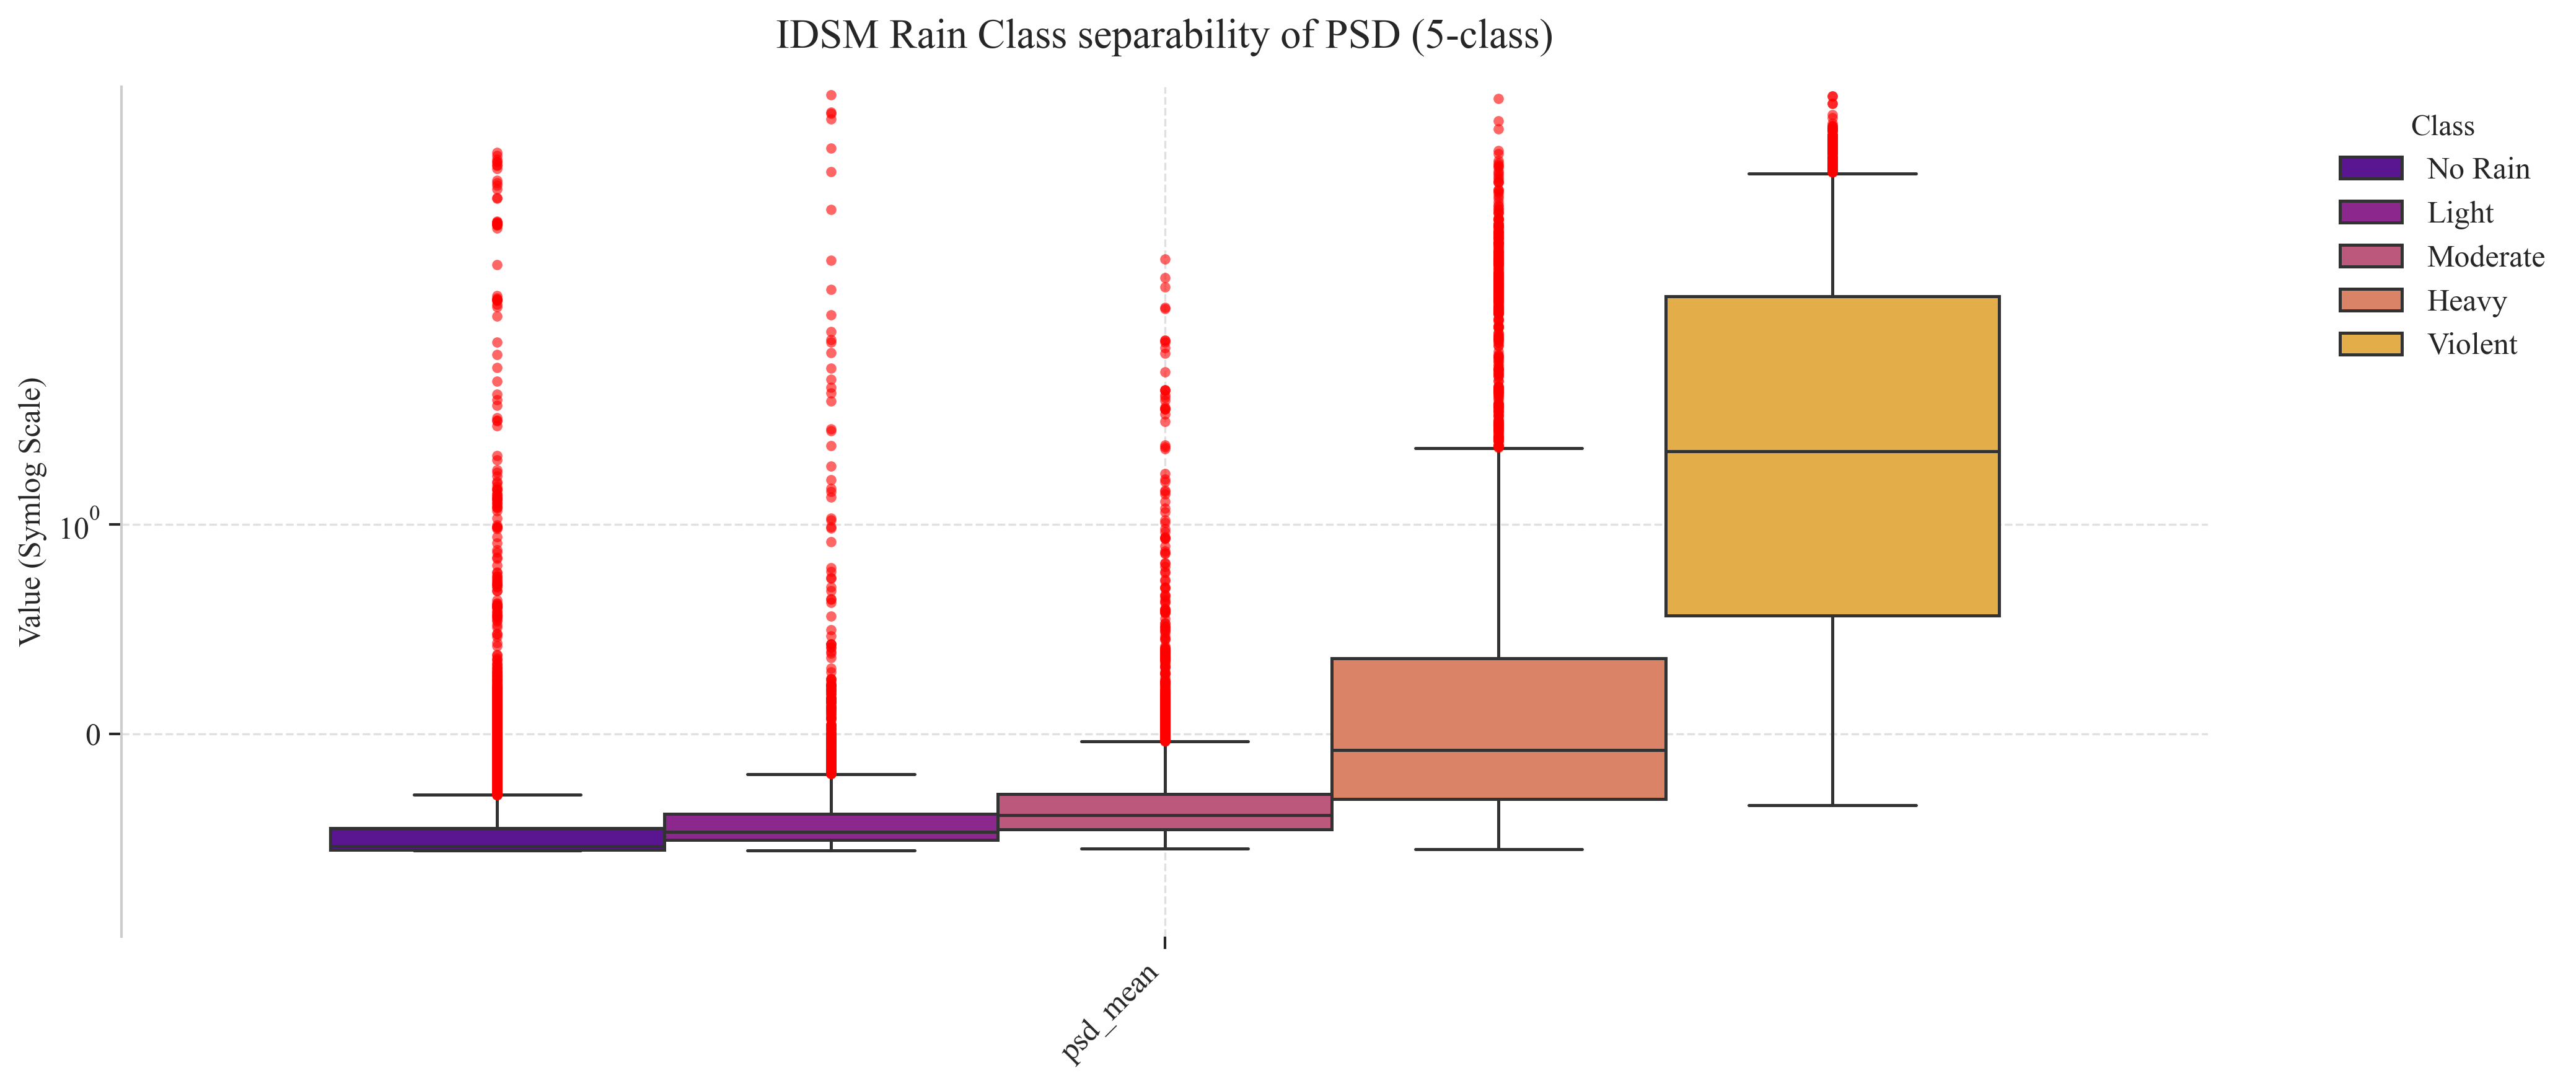

In [11]:
plt_psd_fs = plot_feature_separability(
    X=X_train_psd,
    y=y_train,
    features_to_plot=['psd_mean'],
    title="IDSM Rain Class separability of PSD (5-class)",
    palette=rain_palette
)
viz_engine.save_figure(fig=plt_psd_fs, filename="IDSM_psd_separability_5c", formats=['pdf'])

# Modeling

In [7]:
def record_experiment_results(
    model_name: str,
    feature_set: str,
    report: Dict[str, Any],
    results_accumulator: List[Dict[str, Any]],
    matrices_dir: str = "reports/matrices"
) -> None:
    """
    Extracts scalar metrics for tabular consolidation and serializes
    confusion matrices to a compressed binary format for later visualization.

    This function adheres to a functional approach by explicitly requiring 
    the accumulator list, avoiding hidden global state mutations.

    Parameters
    ----------
    model_name : str
        The name or identifier of the evaluated model (e.g., 'Random Forest').
    report : Dict[str, Any]
        The comprehensive evaluation dictionary generated by `evaluate_model`.
        Expected to contain scalar metrics and matrix keys ('conf_matrix', 
        'norm_conf_matrix', 'classes').
    results_accumulator : List[Dict[str, Any]]
        A reference to the list where the extracted scalar metrics will be 
        appended. This list is intended to be converted to a pandas DataFrame.
    matrices_dir : str, default='reports/matrices'
        The directory path where the compressed .npz matrix files will be saved.
    """
    # 1. Scalar Metric Extraction
    scalars = {
        k: v for k, v in report.items() 
        if isinstance(v, (int, float, np.number))
    }
    
    # Standardize the algorithm name column
    scalars['Algorithm'] = model_name
    scalars['Feature Set'] = feature_set
    
    # Explicit state mutation (Dependency Injection)
    results_accumulator.append(scalars)

    # 2. Directory Assurance
    os.makedirs(matrices_dir, exist_ok=True)

    # 3. Secure Matrix Serialization
    safe_name = model_name.replace(" ", "_").lower()
    safe_feat = feature_set.replace(" ", "_").lower()
    file_path = os.path.join(matrices_dir, f"cm_{safe_name}_{safe_feat}.npz")

    # .get() is used defensively to prevent KeyError if a matrix is missing
    np.savez_compressed(
        file_path,
        raw=report.get('conf_matrix', np.array([])),
        norm=report.get('norm_conf_matrix', np.array([])),
        classes=report.get('classes', [])
    )

In [8]:
validation_results = []

base_sgd = ClassifierFactory.build(
    model_type='sgd', 
    random_state=42, 
    n_jobs=-1
)
base_lr = ClassifierFactory.build(
    model_type='lr', 
    random_state=42, 
    n_jobs=-1
)
base_rf = ClassifierFactory.build(
    model_type='rf', 
    random_state=42, 
    n_jobs=-1
)
base_xgb = ClassifierFactory.build(
    model_type='xgb', 
    random_state=42, 
    n_jobs=-1
)


param_grid_sgd = {
    'alpha': [0.0001, 0.001], 
    'penalty': ['l2', 'elasticnet'],
}

param_grid_lr = {
    'C': [0.1, 1.0, 10.0], 
    'solver': ['lbfgs'], 
    'max_iter': [1000]
}

param_grid_rf = {
    'n_estimators': [100, 200], 
    'max_depth': [None, 5, 10],
    'min_samples_leaf': [1, 2]
}

param_grid_xgb = {
    'n_estimators': [100, 200], 
    'max_depth': [3, 5], 
    'learning_rate': [0.01, 0.1]
}

13:37:15 - [ClassifierFactory] - INFO - CPU Scaling: Requested -1 -> Allocated 26 cores.
13:37:15 - [ClassifierFactory] - INFO - Building registered model architecture: SGD
13:37:15 - [ClassifierFactory] - INFO - CPU Scaling: Requested -1 -> Allocated 26 cores.
13:37:15 - [ClassifierFactory] - INFO - Building registered model architecture: LR
13:37:15 - [ClassifierFactory] - INFO - CPU Scaling: Requested -1 -> Allocated 26 cores.
13:37:15 - [ClassifierFactory] - INFO - Building registered model architecture: RF
13:37:15 - [ClassifierFactory] - INFO - CPU Scaling: Requested -1 -> Allocated 26 cores.
13:37:15 - [ClassifierFactory] - INFO - Building registered model architecture: XGB


## PSD

In [14]:
champion_psd_sgd = optimize_model(
    estimator=base_sgd,
    param_grid=param_grid_sgd,
    X_train=X_train_psd, y_train=y_train,
    X_val=X_val_psd, y_val=y_val,
    scoring_metric='f1_macro'
)

y_pred_psd_sgd = champion_psd_sgd.predict(X_test_psd)
y_proba_psd_sgd = champion_psd_sgd.predict_proba(X_test_psd)

sgd_psd_report = evaluate_model(y_test, y_pred_psd_sgd, y_proba_psd_sgd, classes=['No Rain', 'Light', 'Moderate', 'Heavy', 'Violent'])

record_experiment_results(model_name="Stochastic Gradient Descent", feature_set='psd', report=sgd_psd_report, results_accumulator=validation_results)

10:32:55 - [HyperparameterTuner] - INFO - Starting optimization | Metric: f1_macro | Cores: 26
Fitting 1 folds for each of 4 candidates, totalling 4 fits
10:32:56 - [HyperparameterTuner] - INFO - Optimization Finished | Best f1_macro: 0.3047
10:32:56 - [HyperparameterTuner] - INFO - Refitting the champion model strictly on the Training Set...
10:32:56 - [ValidationModule] - INFO - Evaluation complete.


In [15]:
champion_psd_lr = optimize_model(
    estimator=base_lr,
    param_grid=param_grid_lr,
    X_train=X_train_psd, y_train=y_train,
    X_val=X_val_psd, y_val=y_val,
    scoring_metric='f1_macro'
)

y_pred_psd_lr = champion_psd_lr.predict(X_test_psd)
y_proba_psd_lr = champion_psd_lr.predict_proba(X_test_psd)

lr_psd_report = evaluate_model(y_test, y_pred_psd_lr, y_proba_psd_lr, classes=['No Rain', 'Light', 'Moderate', 'Heavy', 'Violent'])

record_experiment_results(model_name="Logistic Regression", feature_set='psd', report=lr_psd_report, results_accumulator=validation_results)

10:32:56 - [HyperparameterTuner] - INFO - Starting optimization | Metric: f1_macro | Cores: 26
Fitting 1 folds for each of 3 candidates, totalling 3 fits
10:32:57 - [HyperparameterTuner] - INFO - Optimization Finished | Best f1_macro: 0.1885
10:32:57 - [HyperparameterTuner] - INFO - Refitting the champion model strictly on the Training Set...
10:32:57 - [ValidationModule] - INFO - Evaluation complete.


In [16]:
champion_psd_rf = optimize_model(
    estimator=base_rf,
    param_grid=param_grid_rf,
    X_train=X_train_psd, y_train=y_train,
    X_val=X_val_psd, y_val=y_val,
    scoring_metric='f1_macro'
)

y_pred_psd_rf = champion_psd_rf.predict(X_test_psd)
y_proba_psd_rf = champion_psd_rf.predict_proba(X_test_psd)

rf_psd_report = evaluate_model(y_test, y_pred_psd_rf, y_proba_psd_rf, classes=['No Rain', 'Light', 'Moderate', 'Heavy', 'Violent'])

record_experiment_results(model_name="Random Forest", feature_set='psd', report=rf_psd_report, results_accumulator=validation_results)

10:32:57 - [HyperparameterTuner] - INFO - Starting optimization | Metric: f1_macro | Cores: 26
Fitting 1 folds for each of 12 candidates, totalling 12 fits
10:33:01 - [HyperparameterTuner] - INFO - Optimization Finished | Best f1_macro: 0.1897
10:33:01 - [HyperparameterTuner] - INFO - Refitting the champion model strictly on the Training Set...
10:33:01 - [ValidationModule] - INFO - Evaluation complete.


In [17]:
label_map = {
    'No Rain': 0,
    'Light': 1,
    'Moderate': 2,
    'Heavy': 3,
    'Violent': 4
}

y_train_num = y_train.map(label_map)
y_val_num = y_val.map(label_map)
y_test_num = y_test.map(label_map)

champion_psd_xgb = optimize_model(
    estimator=base_xgb,
    param_grid=param_grid_xgb,
    X_train=X_train_psd, y_train=y_train_num,
    X_val=X_val_psd, y_val=y_val_num,
    scoring_metric='f1_macro'
)

y_pred_psd_xgb = champion_psd_xgb.predict(X_test_psd)
y_proba_psd_xgb = champion_psd_xgb.predict_proba(X_test_psd)

xgb_psd_report = evaluate_model(y_test_num, y_pred_psd_xgb, y_proba_psd_xgb, classes=['No Rain', 'Light', 'Moderate', 'Heavy', 'Violent'])

record_experiment_results(model_name="Extreme Gradient Boosting", feature_set='psd', report=xgb_psd_report, results_accumulator=validation_results)

10:33:01 - [HyperparameterTuner] - INFO - Starting optimization | Metric: f1_macro | Cores: 26
Fitting 1 folds for each of 8 candidates, totalling 8 fits
10:33:03 - [HyperparameterTuner] - INFO - Optimization Finished | Best f1_macro: 0.2694
10:33:03 - [HyperparameterTuner] - INFO - Refitting the champion model strictly on the Training Set...
10:33:04 - [ValidationModule] - INFO - Evaluation complete.


## Selected Metrics

In [9]:
champion_selected_metrics_sgd = optimize_model(
    estimator=base_sgd,
    param_grid=param_grid_sgd,
    X_train=X_train_selected_metrics, y_train=y_train,
    X_val=X_val_selected_metrics, y_val=y_val,
    scoring_metric='f1_macro'
)

y_pred_selected_metrics_sgd = champion_selected_metrics_sgd.predict(X_test_selected_metrics)
y_proba_selected_metrics_sgd = champion_selected_metrics_sgd.predict_proba(X_test_selected_metrics)

sgd_selected_metrics_report = evaluate_model(y_test, y_pred_selected_metrics_sgd, y_proba_selected_metrics_sgd, classes=['No Rain', 'Light', 'Moderate', 'Heavy', 'Violent'])

record_experiment_results(model_name="Stochastic Gradient Descent", feature_set='vector', report=sgd_selected_metrics_report, results_accumulator=validation_results)

13:37:19 - [HyperparameterTuner] - INFO - Starting optimization | Metric: f1_macro | Cores: 26
Fitting 1 folds for each of 4 candidates, totalling 4 fits
13:37:21 - [HyperparameterTuner] - INFO - Optimization Finished | Best f1_macro: 0.4878
13:37:21 - [HyperparameterTuner] - INFO - Refitting the champion model strictly on the Training Set...
13:37:21 - [ValidationModule] - INFO - Evaluation complete.


In [10]:
champion_selected_metrics_lr = optimize_model(
    estimator=base_lr,
    param_grid=param_grid_lr,
    X_train=X_train_selected_metrics, y_train=y_train,
    X_val=X_val_selected_metrics, y_val=y_val,
    scoring_metric='f1_macro'
)

y_pred_selected_metrics_lr = champion_selected_metrics_lr.predict(X_test_selected_metrics)
y_proba_selected_metrics_lr = champion_selected_metrics_lr.predict_proba(X_test_selected_metrics)

lr_selected_metrics_report = evaluate_model(y_test, y_pred_selected_metrics_lr, y_proba_selected_metrics_lr, classes=['No Rain', 'Light', 'Moderate', 'Heavy', 'Violent'])

record_experiment_results(model_name="Logistic Regression", feature_set='vector', report=lr_selected_metrics_report, results_accumulator=validation_results)

13:37:21 - [HyperparameterTuner] - INFO - Starting optimization | Metric: f1_macro | Cores: 26
Fitting 1 folds for each of 3 candidates, totalling 3 fits
13:37:23 - [HyperparameterTuner] - INFO - Optimization Finished | Best f1_macro: 0.4086
13:37:23 - [HyperparameterTuner] - INFO - Refitting the champion model strictly on the Training Set...
13:37:23 - [ValidationModule] - INFO - Evaluation complete.


In [11]:
champion_selected_metrics_rf = optimize_model(
    estimator=base_rf,
    param_grid=param_grid_rf,
    X_train=X_train_selected_metrics, y_train=y_train,
    X_val=X_val_selected_metrics, y_val=y_val,
    scoring_metric='f1_macro'
)

y_pred_selected_metrics_rf = champion_selected_metrics_rf.predict(X_test_selected_metrics)
y_proba_selected_metrics_rf = champion_selected_metrics_rf.predict_proba(X_test_selected_metrics)

rf_selected_metrics_report = evaluate_model(y_test, y_pred_selected_metrics_rf, y_proba_selected_metrics_rf, classes=['No Rain', 'Light', 'Moderate', 'Heavy', 'Violent'])

record_experiment_results(model_name="Random Forest", feature_set='vector', report=rf_selected_metrics_report, results_accumulator=validation_results)

13:37:23 - [HyperparameterTuner] - INFO - Starting optimization | Metric: f1_macro | Cores: 26
Fitting 1 folds for each of 12 candidates, totalling 12 fits
13:37:28 - [HyperparameterTuner] - INFO - Optimization Finished | Best f1_macro: 0.3846
13:37:28 - [HyperparameterTuner] - INFO - Refitting the champion model strictly on the Training Set...
13:37:29 - [ValidationModule] - INFO - Evaluation complete.


In [12]:
label_map = {
    'No Rain': 0,
    'Light': 1,
    'Moderate': 2,
    'Heavy': 3,
    'Violent': 4
}

y_train_num = y_train.map(label_map)
y_val_num = y_val.map(label_map)
y_test_num = y_test.map(label_map)

champion_selected_metrics_xgb = optimize_model(
    estimator=base_xgb,
    param_grid=param_grid_xgb,
    X_train=X_train_selected_metrics, y_train=y_train_num,
    X_val=X_val_selected_metrics, y_val=y_val_num,
    scoring_metric='f1_macro'
)

y_pred_selected_metrics_xgb = champion_selected_metrics_xgb.predict(X_test_selected_metrics)
y_proba_selected_metrics_xgb = champion_selected_metrics_xgb.predict_proba(X_test_selected_metrics)

xgb_selected_metrics_report = evaluate_model(y_test_num, y_pred_selected_metrics_xgb, y_proba_selected_metrics_xgb, classes=['No Rain', 'Light', 'Moderate', 'Heavy', 'Violent'])

record_experiment_results(model_name="Extreme Gradient Boosting", feature_set='vector', report=xgb_selected_metrics_report, results_accumulator=validation_results)

13:37:29 - [HyperparameterTuner] - INFO - Starting optimization | Metric: f1_macro | Cores: 26
Fitting 1 folds for each of 8 candidates, totalling 8 fits
13:37:32 - [HyperparameterTuner] - INFO - Optimization Finished | Best f1_macro: 0.3292
13:37:32 - [HyperparameterTuner] - INFO - Refitting the champion model strictly on the Training Set...
13:37:33 - [ValidationModule] - INFO - Evaluation complete.


In [22]:
validation_results_path = DATA_DIR / "5c_validation_results.csv"

df_validation_results = pd.DataFrame(validation_results)
df_validation_results.to_csv(validation_results_path, index=False)

In [13]:
import numpy as np
from rainfall_acoustic_classification.visualization import (
    plot_confusion_matrix,
    plot_multimodel_pr_curves
)

def get_aligned_probs(model, X, target_classes, model_classes, mapping=None):
    if hasattr(model, 'feature_names_in_'):
        X_aligned = X[model.feature_names_in_]
    else:
        X_aligned = X
        
    probs = model.predict_proba(X_aligned)
    
    if mapping:
        indices = [list(model_classes).index(mapping[c]) for c in target_classes]
    else:
        indices = [list(model_classes).index(c) for c in target_classes]
        
    return probs[:, indices]

problem_classes = list(rain_palette.keys())

y_probs_dict = {}

y_probs_dict['Stochastic Gradient Descent'] = get_aligned_probs(champion_selected_metrics_sgd, X_test, problem_classes, champion_selected_metrics_sgd.classes_)
y_probs_dict['Logistic Regression'] = get_aligned_probs(champion_selected_metrics_lr, X_test, problem_classes, champion_selected_metrics_lr.classes_)
y_probs_dict['Random Forest'] = get_aligned_probs(champion_selected_metrics_rf, X_test, problem_classes, champion_selected_metrics_rf.classes_)
y_probs_dict['Extreme Gradient Boosting'] = get_aligned_probs(champion_selected_metrics_xgb, X_test, problem_classes, champion_selected_metrics_xgb.classes_, mapping=label_map)

12:52:05 - [VizEngine] - INFO - Figure saved: IDSM_vector_pr-auc_5c.pdf


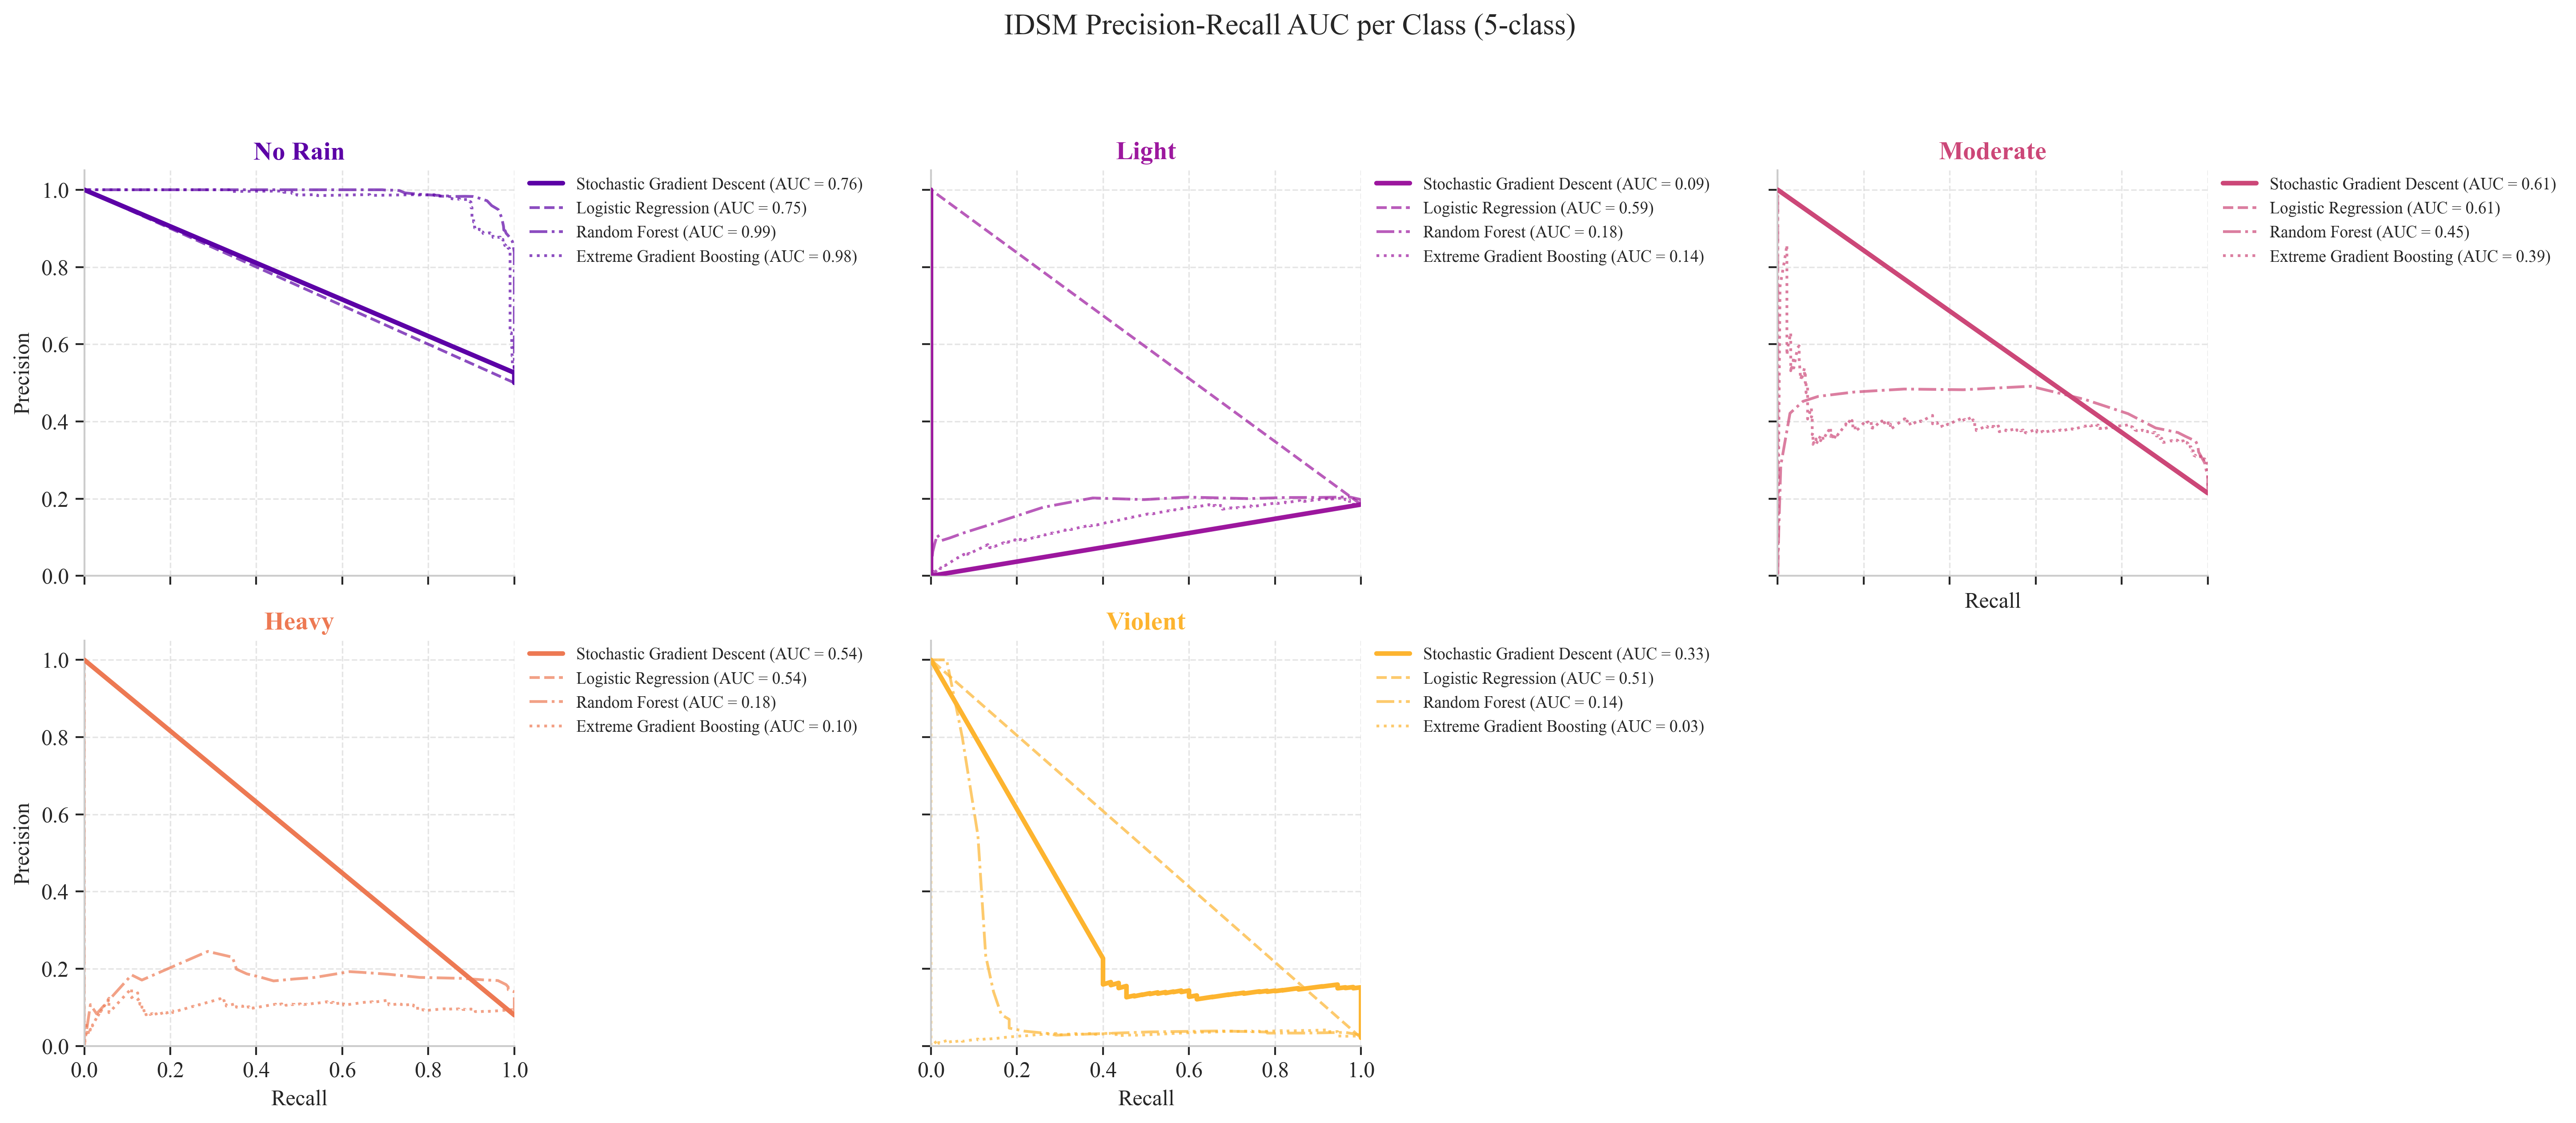

In [ ]:
plt_vector_pr_auc = plot_multimodel_pr_curves(
    y_true=y_test.values if hasattr(y_test, 'values') else y_test,
    y_probs_dict=y_probs_dict,
    palette=rain_palette,
    champion_models=['Stochastic Gradient Descent'],
    title="IDSM Precision-Recall AUC per Class (5-class)"
)
viz_engine.save_figure(fig=plt_vector_pr_auc, filename="IDSM_vector_pr-auc_5c", formats=['pdf'])

13:47:22 - [VizEngine] - INFO - Figure saved: IDSM_vector_confusion_matrix_5c_sgd_raw.pdf
13:47:22 - [VizEngine] - INFO - Figure saved: IDSM_vector_confusion_matrix_5c_logistic_regression_raw.pdf
13:47:22 - [VizEngine] - INFO - Figure saved: IDSM_vector_confusion_matrix_5c_random_forest_raw.pdf
13:47:22 - [VizEngine] - INFO - Figure saved: IDSM_vector_confusion_matrix_5c_xgboost_raw.pdf


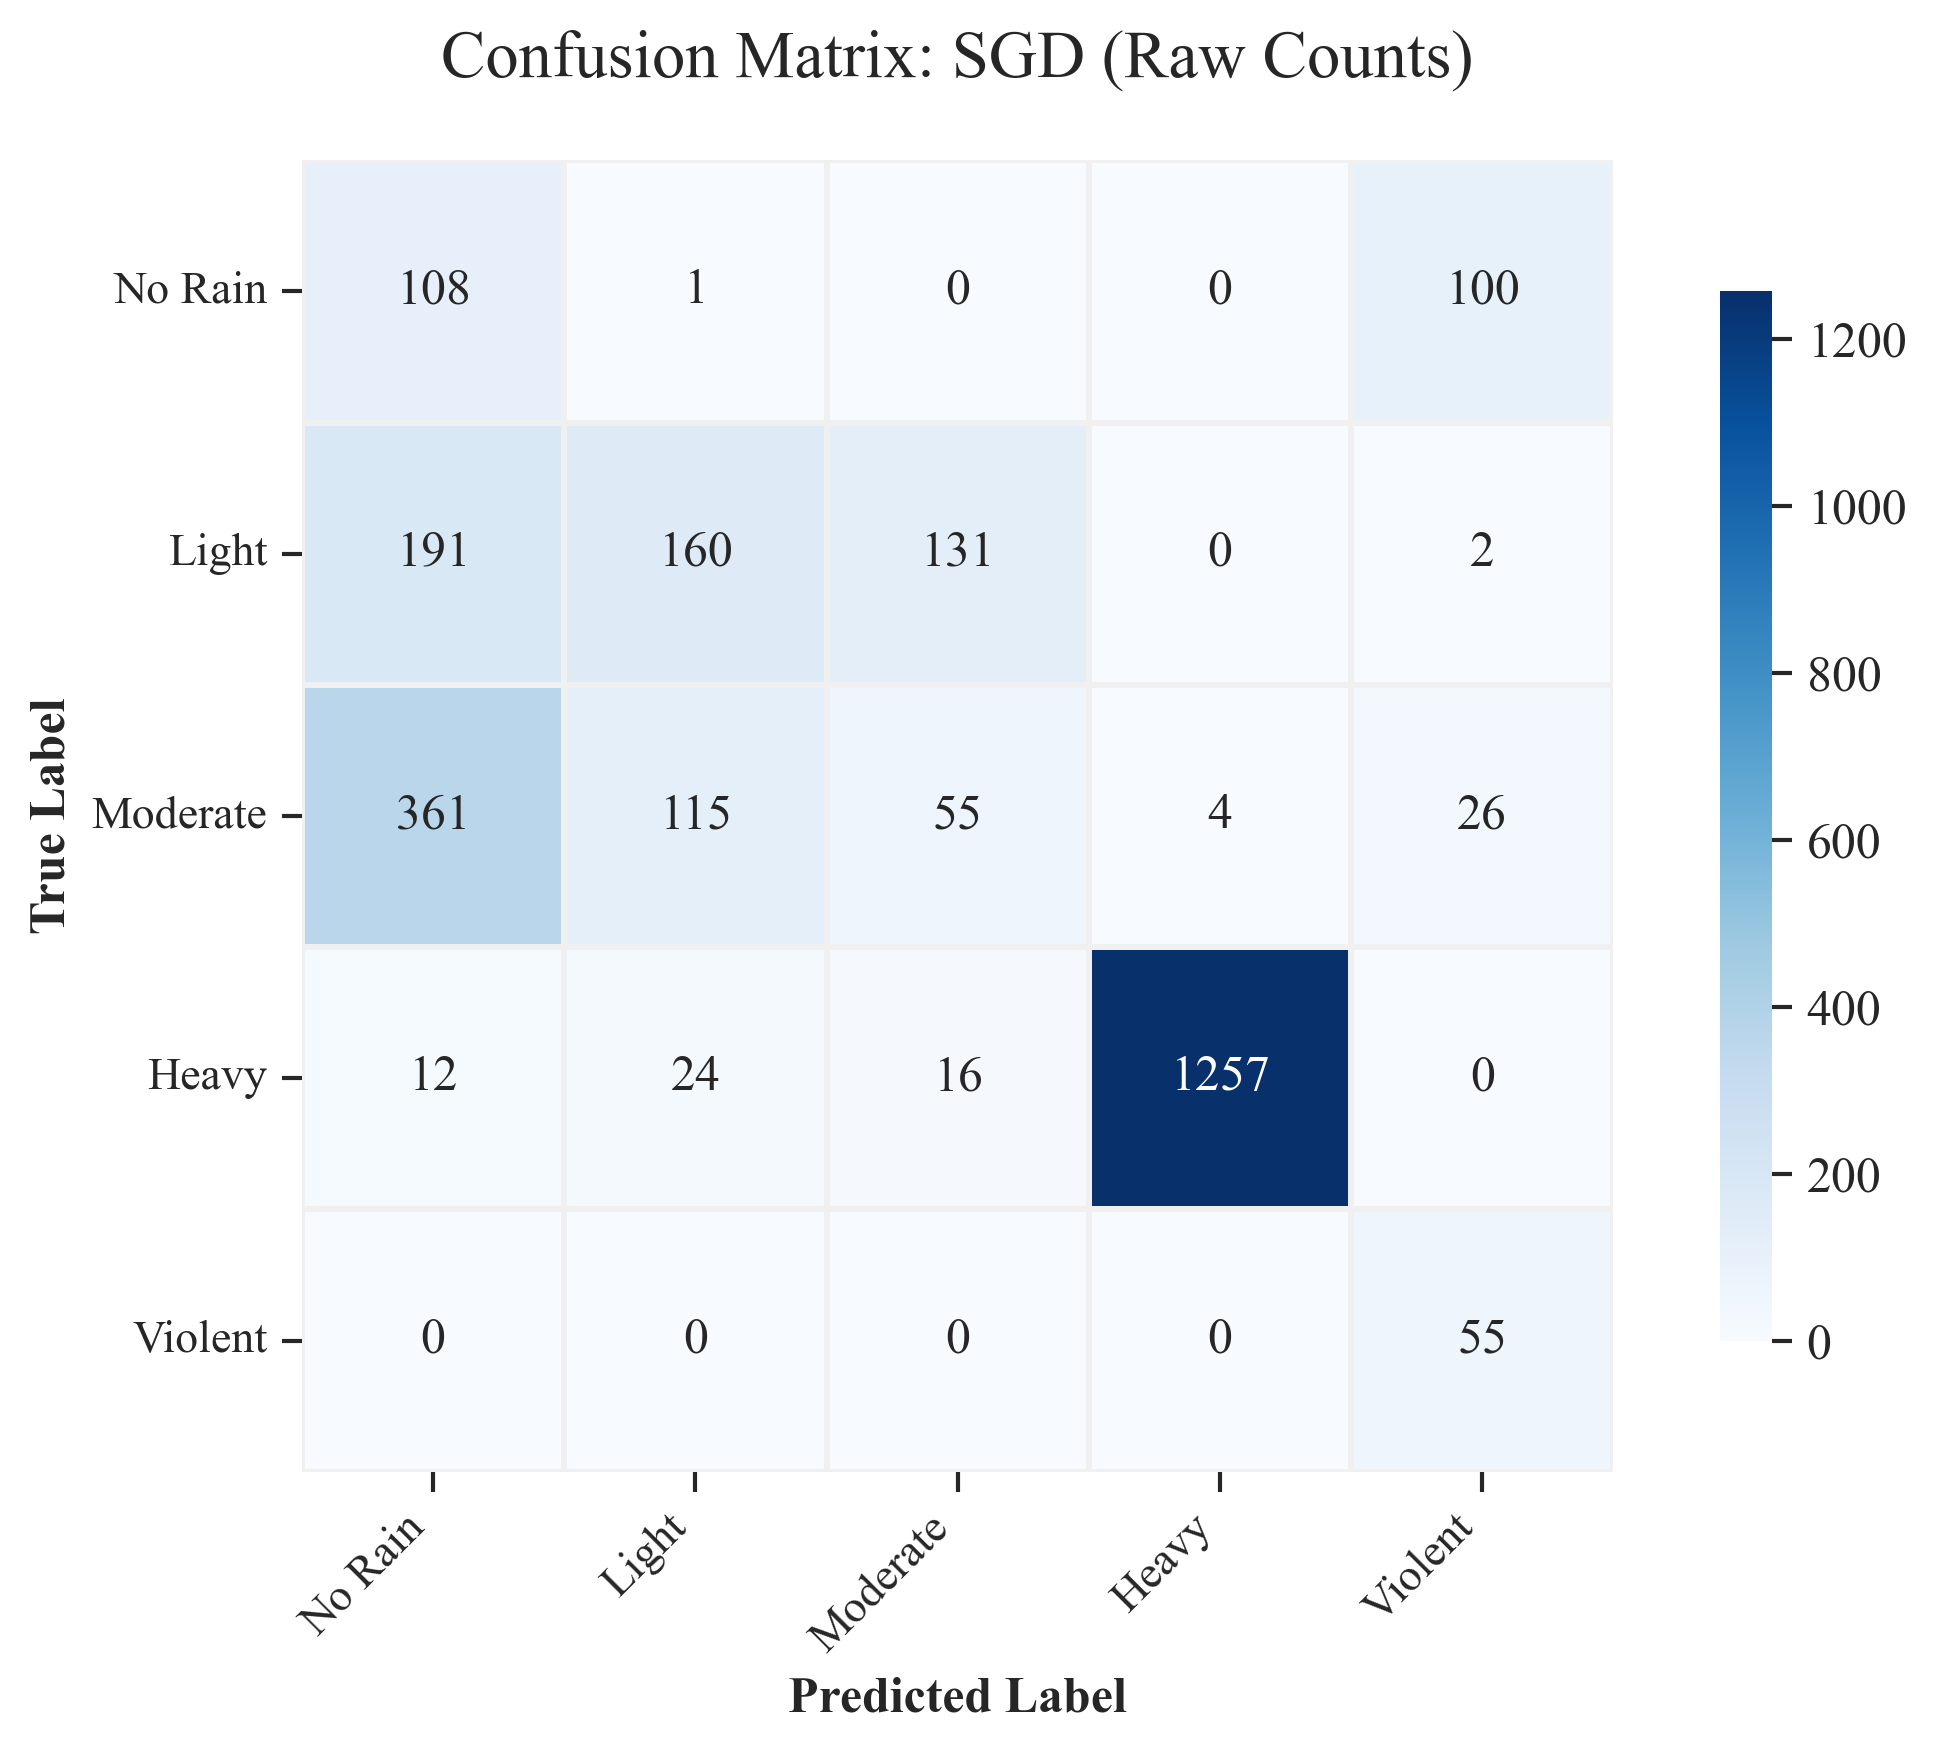

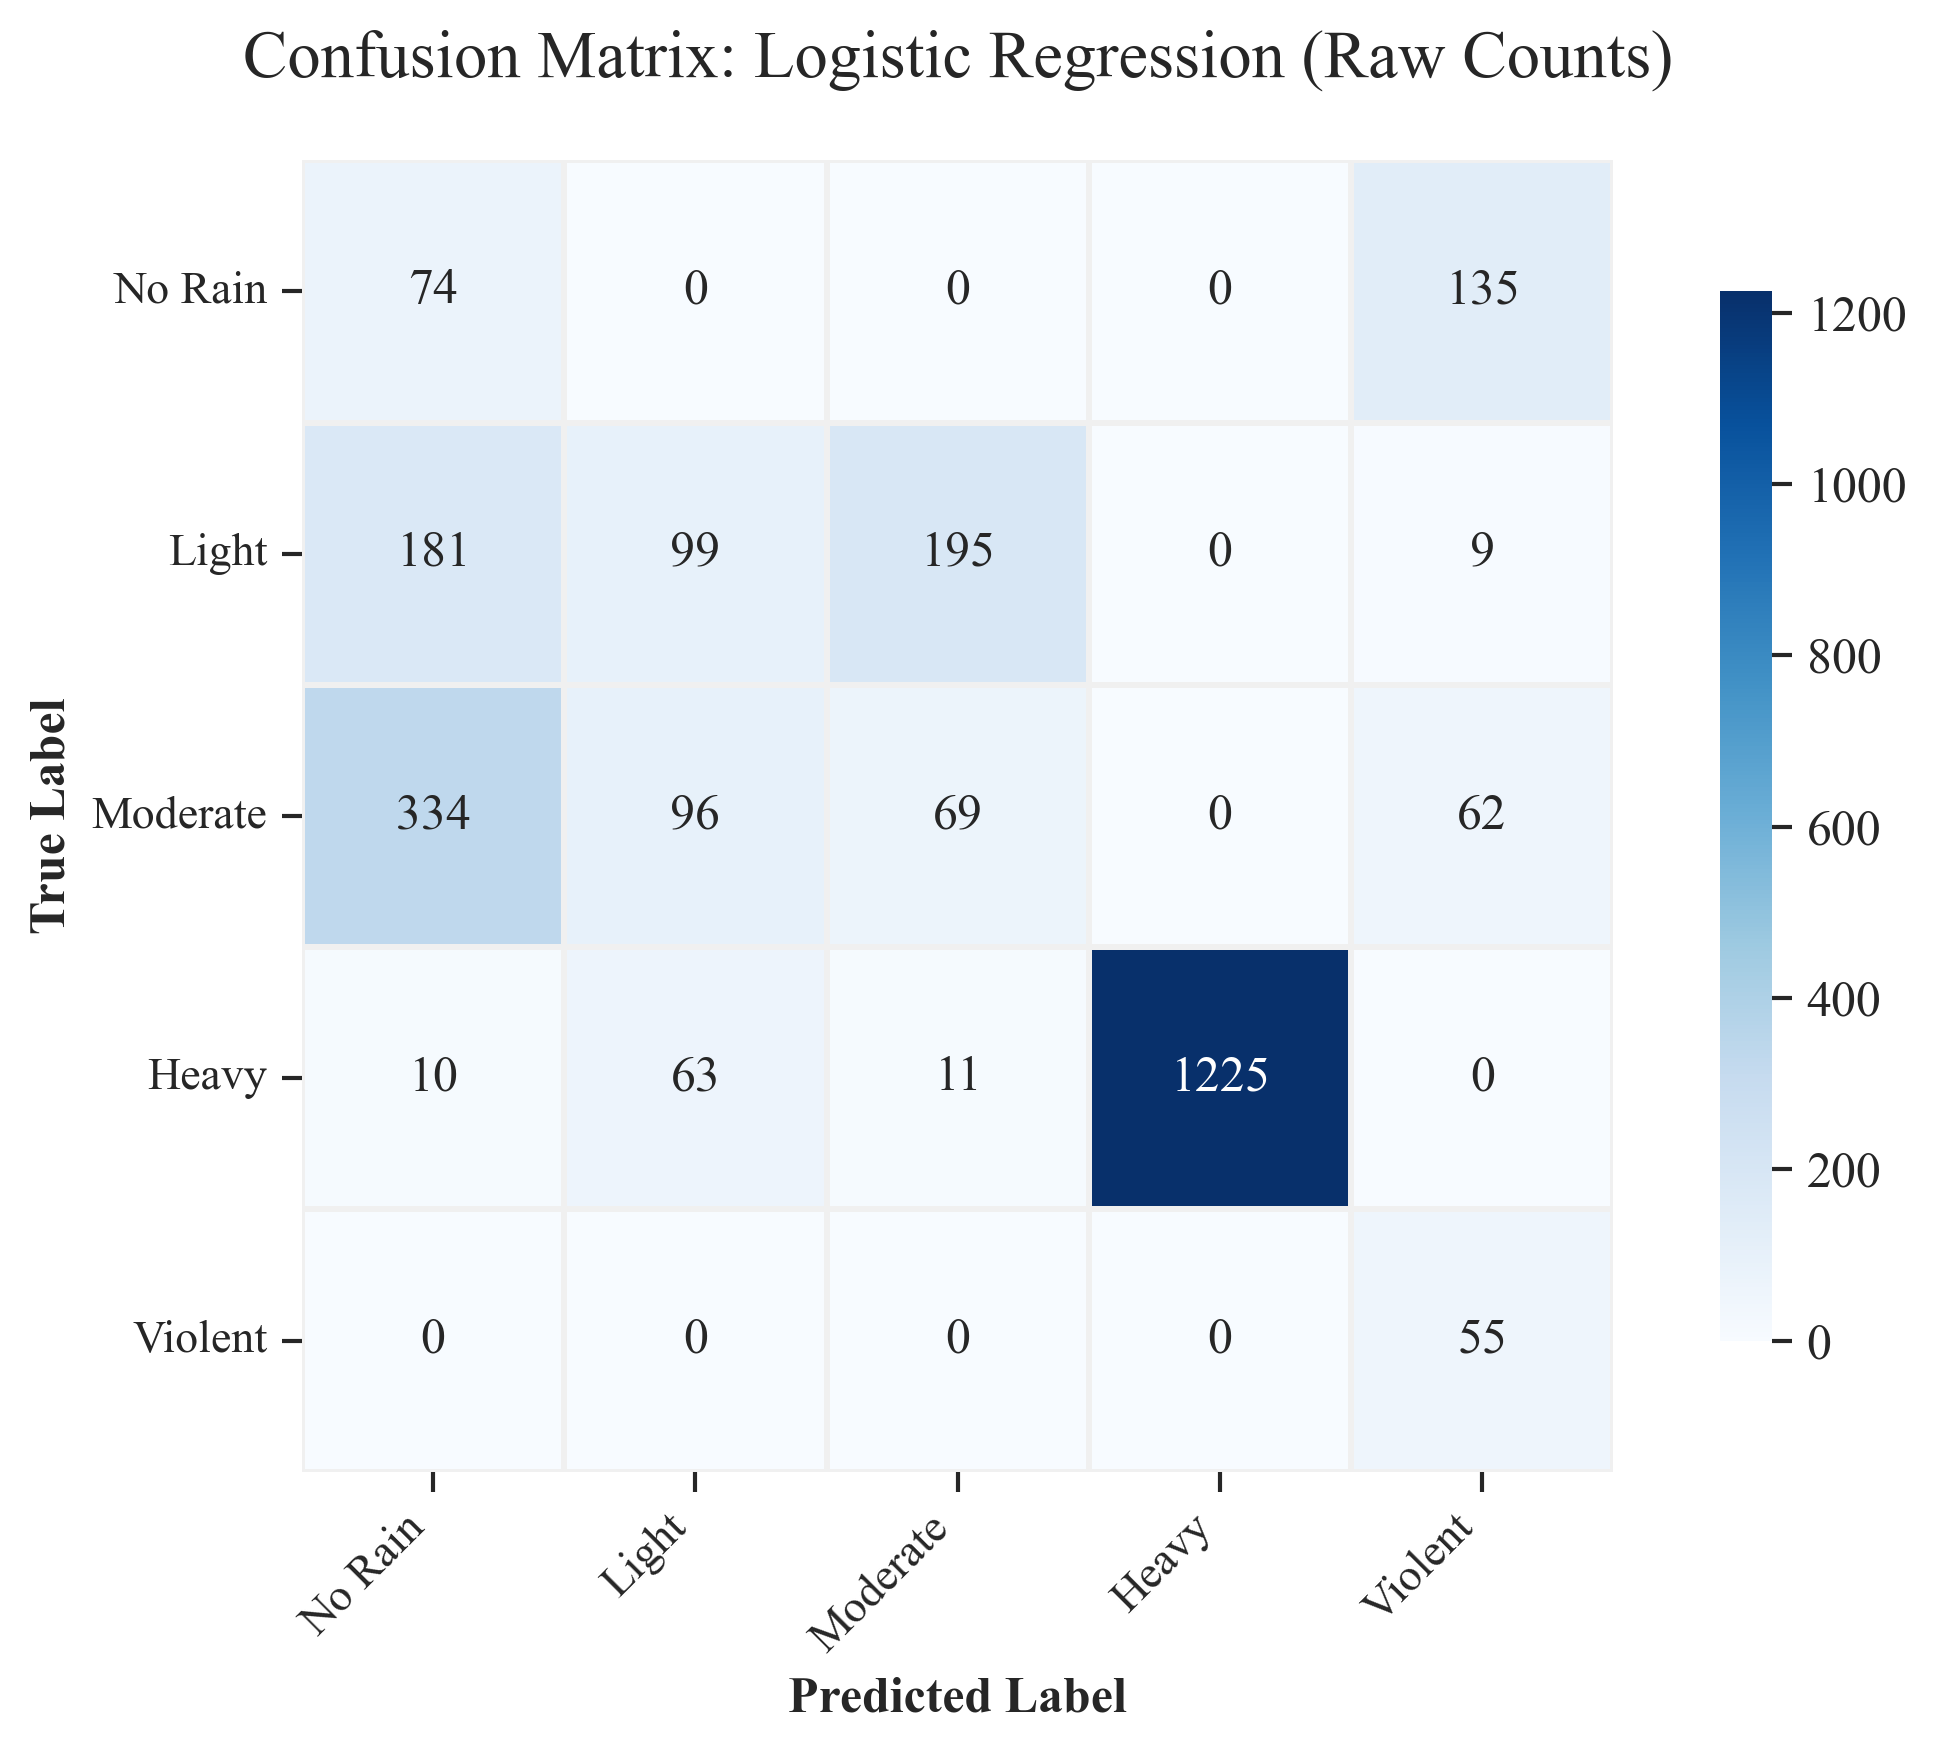

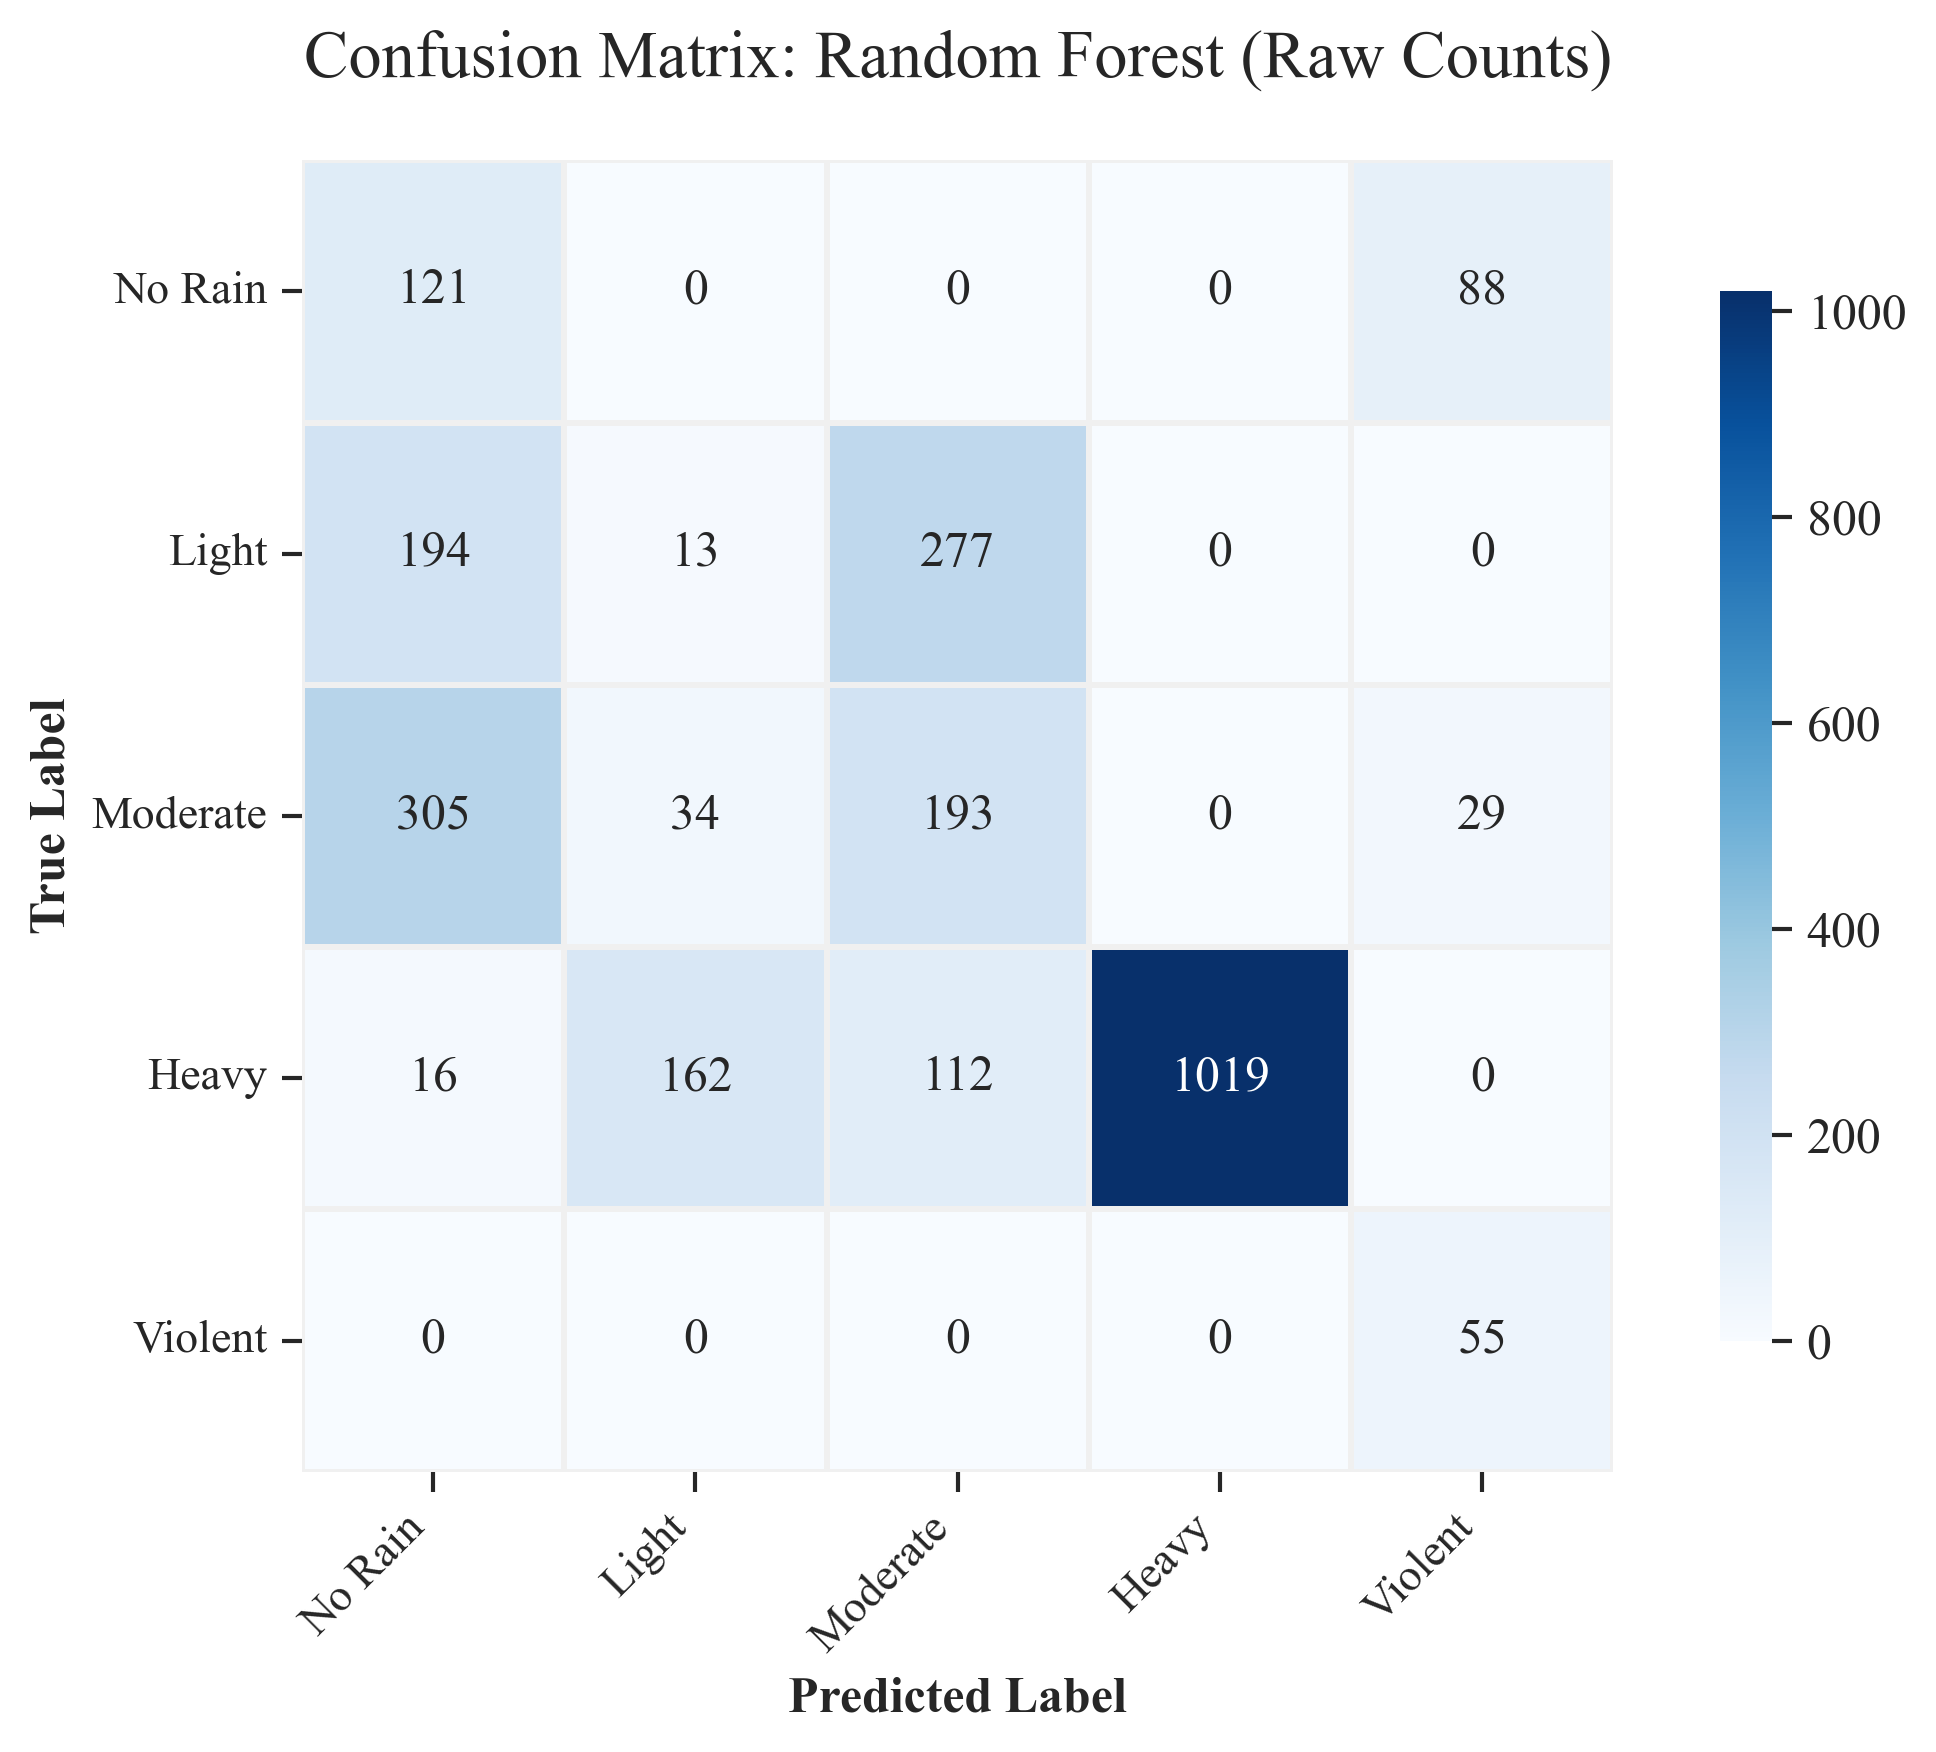

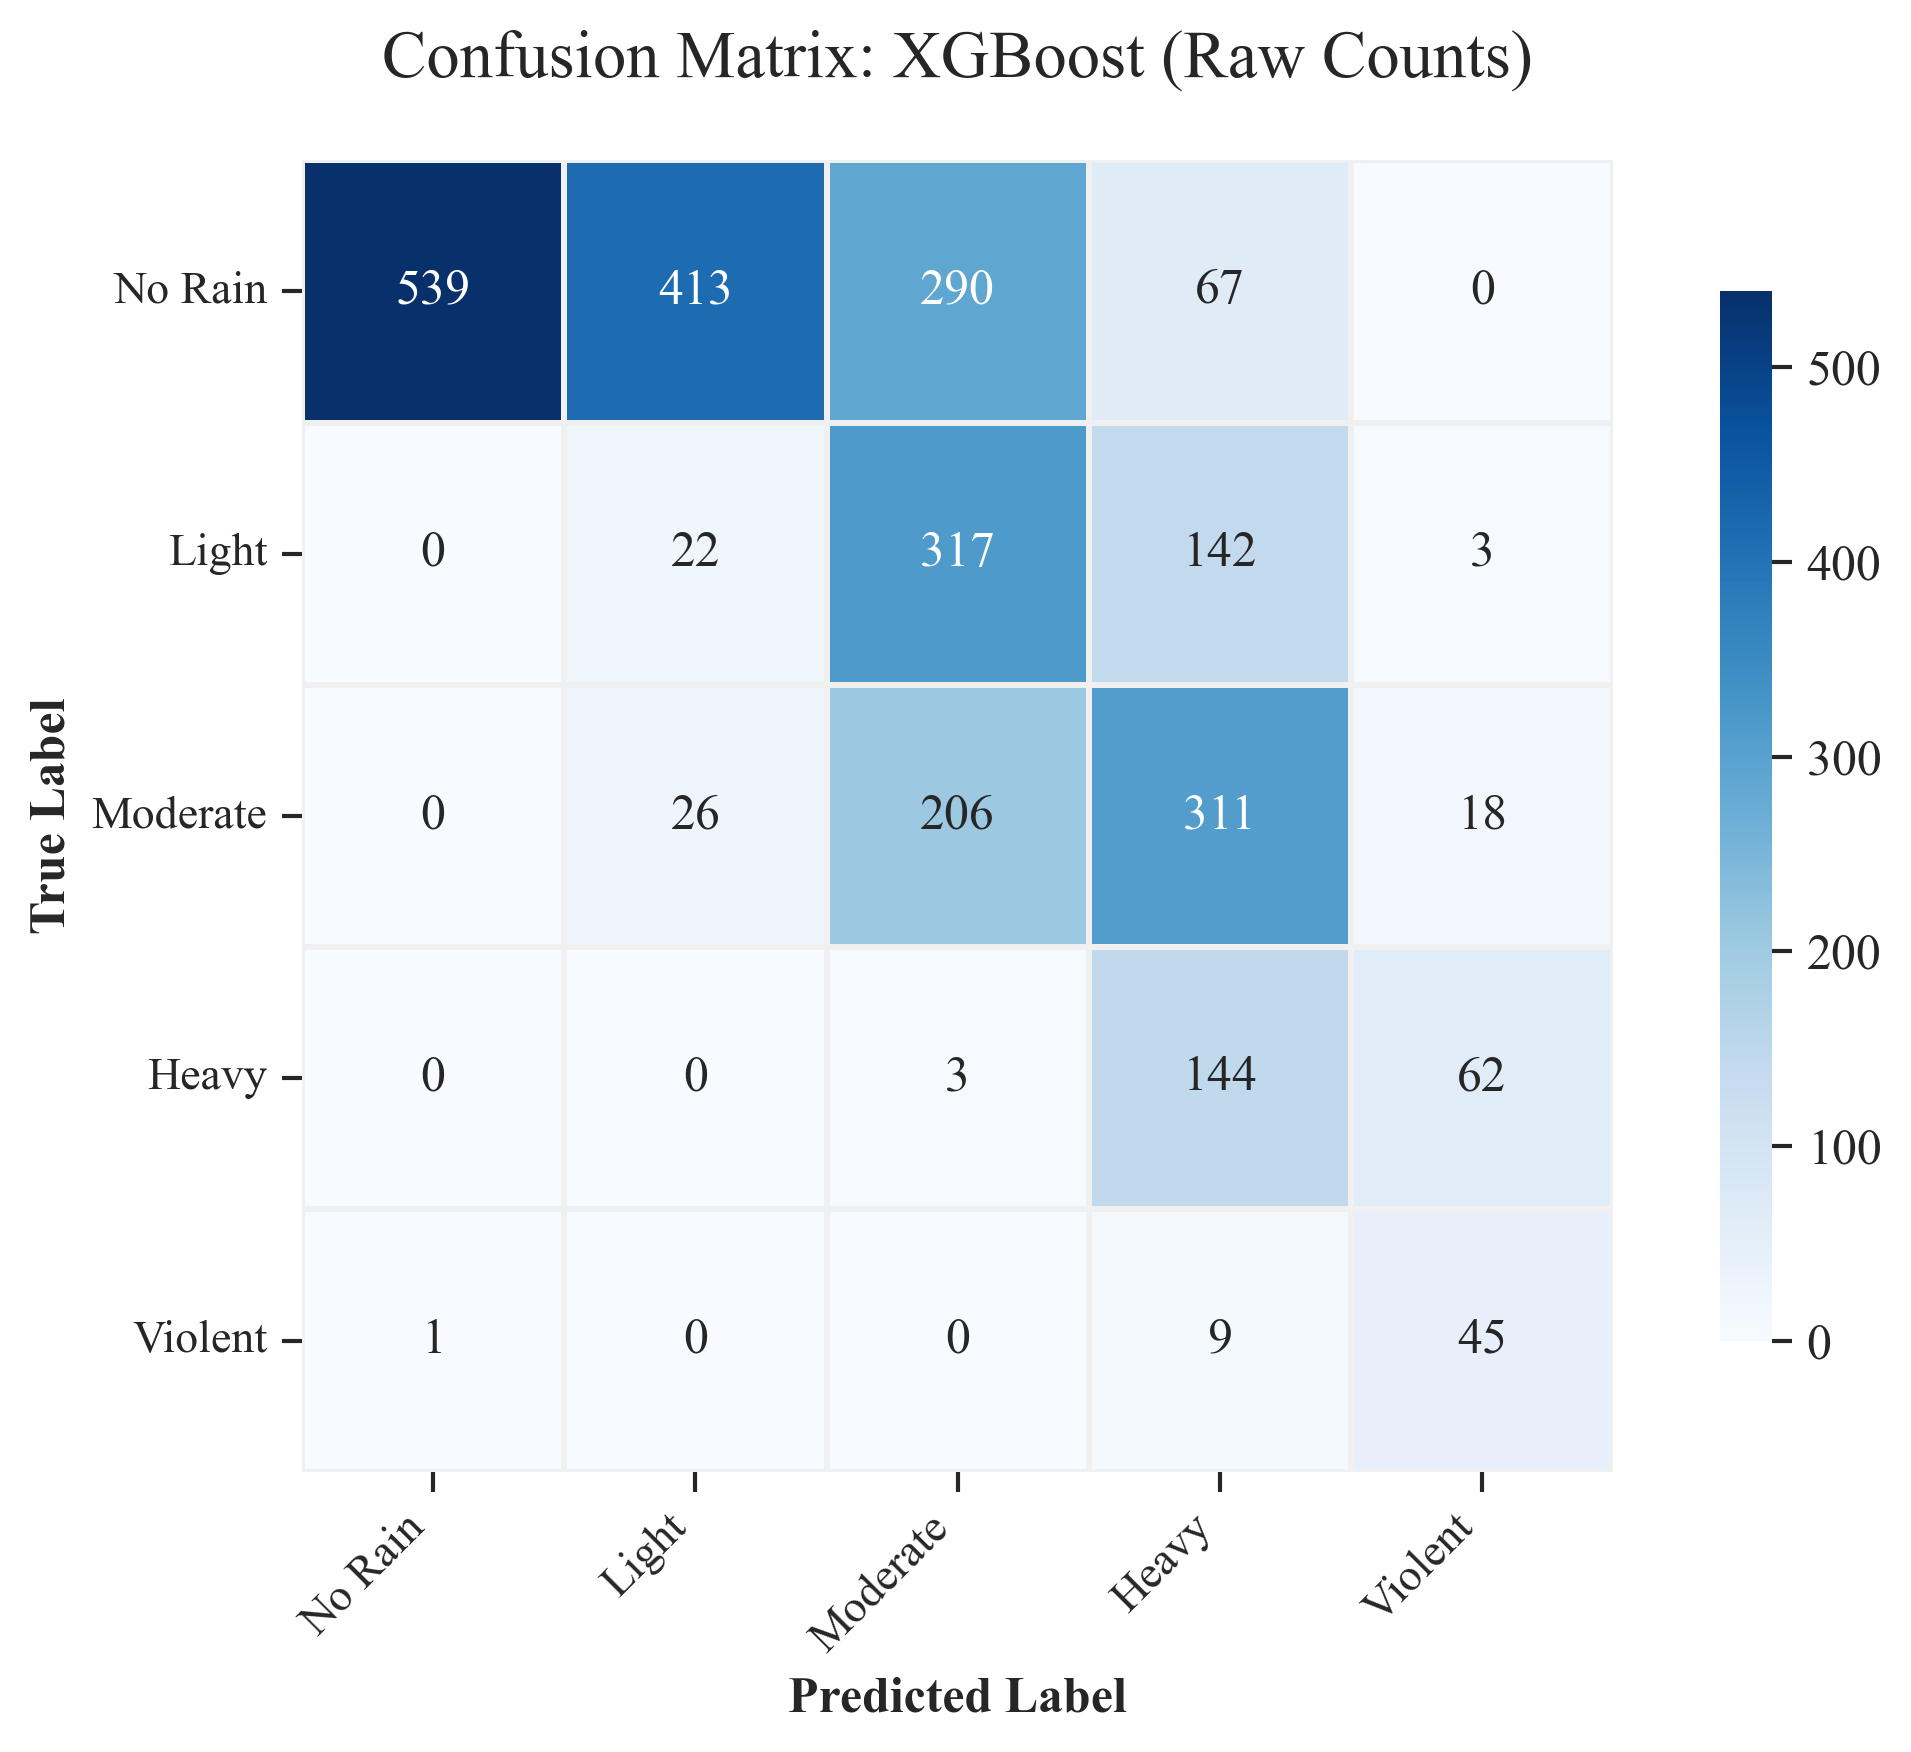

In [20]:
reports_dict = {
    'SGD': sgd_selected_metrics_report,
    'Logistic Regression': lr_selected_metrics_report,
    'Random Forest': rf_selected_metrics_report,
    'XGBoost': xgb_selected_metrics_report
}

use_normalized = False 

problem_classes = list(label_map.keys()) 

for model_name, report in reports_dict.items():
    cm_raw = report['conf_matrix'] 
    
    cm_df = pd.DataFrame(cm_raw, index=problem_classes, columns=problem_classes)
    
    if use_normalized:
        cm_df = cm_df.div(cm_df.sum(axis=1), axis=0)
    
    title_suffix = "(Normalized)" if use_normalized else "(Raw Counts)"
    fig = plot_confusion_matrix(
        cm_df=cm_df,
        title=f"Confusion Matrix: {model_name} {title_suffix}",
        is_normalized=use_normalized
    )
    
    filename_suffix = "norm" if use_normalized else "raw"
    safe_filename = f"IDSM_vector_confusion_matrix_5c_{model_name.lower().replace(' ', '_')}_{filename_suffix}"
    viz_engine.save_figure(fig, safe_filename,formats=['pdf'])

In [21]:
import pprint

modelos_campeoes = {
    'SGD': champion_selected_metrics_sgd,
    'Logistic Regression': champion_selected_metrics_lr,
    'Random Forest': champion_selected_metrics_rf,
    'XGBoost': champion_selected_metrics_xgb
}

for nome_modelo, modelo in modelos_campeoes.items():
    print(f"\n{'='*40}")
    print(f"Hiperparâmetros: {nome_modelo}")
    print(f"{'='*40}")
    
    parametros = modelo.get_params()
    
    pprint.pprint(parametros, indent=4)


Hiperparâmetros: SGD
{   'alpha': 0.001,
    'average': False,
    'class_weight': 'balanced',
    'early_stopping': False,
    'epsilon': 0.1,
    'eta0': 0.01,
    'fit_intercept': True,
    'l1_ratio': 0.15,
    'learning_rate': 'optimal',
    'loss': 'log_loss',
    'max_iter': 1000,
    'n_iter_no_change': 5,
    'n_jobs': 26,
    'penalty': 'l2',
    'power_t': 0.5,
    'random_state': 42,
    'shuffle': True,
    'tol': 0.001,
    'validation_fraction': 0.1,
    'verbose': 0,
    'warm_start': False}

Hiperparâmetros: Logistic Regression
{   'C': 0.1,
    'class_weight': 'balanced',
    'dual': False,
    'fit_intercept': True,
    'intercept_scaling': 1,
    'l1_ratio': 0.0,
    'max_iter': 1000,
    'n_jobs': 26,
    'penalty': 'deprecated',
    'random_state': 42,
    'solver': 'lbfgs',
    'tol': 0.0001,
    'verbose': 0,
    'warm_start': False}

Hiperparâmetros: Random Forest
{   'bootstrap': True,
    'ccp_alpha': 0.0,
    'class_weight': 'balanced',
    'criterion': 'gi